# Block 1 - Overview EDA on the eICU-CRD patient table

**Project:** Evolving Interpretable Sepsis Mortality Risk Scores via Genetic Programming
**Notebook:** `NB01_overview_eda.ipynb`
**Author:** Neelofar Shaheen
**Course:** IT9115

---

## Purpose

This notebook produces the baseline snapshot of the eICU-CRD v2.0 dataset before any cohort filtering is applied. The numbers and figures here serve as the denominator for the sequential filtering tables produced in Block 2 (`NB02_cohort_construction.ipynb`).

All analysis is read-only with respect to raw data: no derived tables are written back into `data/raw/`. Outputs (figures, summary tables) are saved to `results/figures/` and `results/tables/`.

## Block 1 deliverables

| # | Deliverable | Output file(s) |
|---|---|---|
| 1.1 | Schema description of `patient.csv.gz` | `results/tables/01_patient_schema.csv` |
| 1.2 | Patient / stay / hospital counts | `results/tables/01_baseline_counts.csv` |
| 1.3 | Demographics: age, gender, ethnicity | `results/figures/01_demographics.png`, `results/tables/01_demographics_summary.csv` |
| 1.4 | Hospital and ICU-unit landscape | `results/figures/01_hospital_landscape.png`, `results/figures/01_unit_types.png` |
| 1.5 | Length-of-stay distributions | `results/figures/01_los_distributions.png` |
| 1.6 | Baseline mortality rates | `results/tables/01_baseline_mortality.csv` |

Each cell below is preceded by a **Plan** markdown and followed by a **Findings** markdown that records the observed output and its interpretation.


---
## Cell 1 - Setup

**Plan.** Initialise the analysis environment so that every subsequent cell has access to the central path resolver, consistent plotting defaults, and a verified Python environment.

The cell:
1. Adds the project root to `sys.path` so `from src.paths import P` resolves regardless of the launch directory.
2. Imports the scientific stack (`numpy`, `pandas`, `matplotlib`, `seaborn`) inside a `try`/`except` block that raises a clear error if the kernel does not have these packages installed.
3. Loads the central path resolver (`src/paths.py`) and creates any missing output directories via `ensure_dirs()`.
4. Sets `seaborn` whitegrid theme, DPI 100 on-screen / 150 saved, consistent font sizing.
5. Prints a status block: library versions, project root, eICU data directory, and the list of extracted eICU tables with sizes.


In [18]:
"""Cell 1 - Setup. Imports, paths, plotting defaults, status report."""

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError as exc:
    raise RuntimeError(
        "Required package not found. Make sure the kernel is set to "
        "'Python (sepsis-gp)' (top-right of the notebook UI). "
        f"Underlying error: {exc}"
    ) from exc

from src.paths import P, ensure_dirs
ensure_dirs()

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.titlesize": 12, "axes.labelsize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)

print(
    f"pandas {pd.__version__} | numpy {np.__version__} | "
    f"matplotlib {plt.matplotlib.__version__} | seaborn {sns.__version__}"
)
print(f"Project root:  {PROJECT_ROOT}")
print(f"eICU data dir: {P.eicu_dir}")

print("\nExtracted eICU tables:")
if P.eicu_dir.exists():
    for fp in sorted(P.eicu_dir.glob("*.csv.gz")):
        size_mb = fp.stat().st_size / 1024 / 1024
        print(f"  {fp.name:35s} {size_mb:8.1f} MB")
else:
    print(f"  [WARNING] {P.eicu_dir} does not exist - re-run extraction.")


pandas 3.0.2 | numpy 2.4.3 | matplotlib 3.10.9 | seaborn 0.13.2
Project root:  c:\ML PROJECT\sepsis-gp
eICU data dir: C:\ML PROJECT\sepsis-gp\data\raw\eicu

Extracted eICU tables:
  admissionDx.csv.gz                       7.3 MB
  apacheApsVar.csv.gz                      4.9 MB
  apachePatientResult.csv.gz              16.5 MB
  apachePredVar.csv.gz                     3.7 MB
  diagnosis.csv.gz                        33.6 MB
  hospital.csv.gz                          0.0 MB
  infusionDrug.csv.gz                     46.7 MB
  lab.csv.gz                             432.2 MB
  medication.csv.gz                      128.1 MB
  pastHistory.csv.gz                      12.4 MB
  patient.csv.gz                           9.9 MB
  respiratoryCare.csv.gz                   8.6 MB
  treatment.csv.gz                        40.8 MB
  vitalAperiodic.csv.gz                  228.5 MB


### Findings - Cell 1

**Output observed.** Library versions reported as pandas 3.0.2, numpy 2.4.3, matplotlib 3.10.9, seaborn 0.13.2. Project root and eICU data directory both resolve under `C:\ML PROJECT\sepsis-gp\`. Fourteen extracted eICU tables are listed.

**Interpretation.** The kernel resolves correctly to the `sepsis-gp` conda environment. All extracted eICU tables are present in `data/raw/eicu/`. The `lab.csv.gz` file is 492.9 MB (39,132,531 rows, complete). An initial download was found to be truncated (432 MB, 34M rows); the complete file was re-downloaded from PhysioNet (Issue B5 resolved in NB03). The partial file did not affect Block 1 work, which operates only on the patient table.


---
## Cell 2 - Load and inspect the patient table

**Plan.** Load `patient.csv.gz` into a `pandas` DataFrame and inspect its anatomy (shape, dtypes, content) before performing any analysis.

The cell:
1. Reads the gzipped CSV via `pd.read_csv(..., low_memory=False)`. The `low_memory=False` flag forces a single-pass read with one dtype per column, avoiding `DtypeWarning` on heterogeneous columns.
2. Reports the shape and the in-memory footprint computed with `memory_usage(deep=True)`.
3. Displays the first three rows as an inline HTML table for direct inspection.
4. Lists every column's dtype.
5. Inspects the top values of the `age` column to confirm the HIPAA Safe Harbor anonymisation convention.


In [ ]:
"""Cell 2 - Load patient.csv.gz and inspect anatomy."""

from IPython.display import display

patient_path = P.eicu_dir / "patient.csv.gz"
print(f"Loading: {patient_path}")

patient = pd.read_csv(patient_path, low_memory=False)

n_rows, n_cols = patient.shape
mem_mb = patient.memory_usage(deep=True).sum() / 1024 / 1024
print(f"Shape: {n_rows:,} rows x {n_cols} columns")
print(f"In-memory size: {mem_mb:.1f} MB")
print()

print("First 3 rows:")
display(patient.head(3))

print("\nColumn dtypes:")
display(patient.dtypes.to_frame("dtype"))

print("\nTop 'age' values (note the '> 89' quirk):")
print(patient["age"].value_counts(dropna=False).head(15))


### Findings - Cell 2

**Output observed.**

- Shape: 200,859 rows x 29 columns.
- In-memory footprint: 75.2 MB.
- Top `age` values: `> 89` (n = 7,081), followed by numeric strings ('67', '68', '72', etc.).
- Rows 1 and 2 of the preview share the same `uniquepid` (002-33870), indicating multiple ICU stays for one patient within one hospital admission.

**Interpretation.** The row count of 200,859 matches the published eICU-CRD v2.0 size exactly, confirming the full dataset is loaded without truncation. The in-memory footprint (75.2 MB) is smaller than initially expected; this is attributable to pandas 3.0's adoption of PyArrow-backed string dtype, which is materially more memory-efficient than the legacy `object` dtype.

The `age` column is stored as a string because patients aged 90 or above are recorded as the literal string `"> 89"` (with a space) under HIPAA Safe Harbor de-identification. 7,081 records exhibit this anonymisation pattern. Numeric ages are also stored as strings (e.g., `"67"`, `"68"`). A cleanup step is required before any numeric statistics can be computed on age; this is implemented in Cell 4.

The shared `uniquepid` between rows 1 and 2 of the preview confirms that one patient can have multiple ICU stays within a single hospital admission. The table grain is therefore *ICU stay*, not *patient* - a distinction with consequences for denominator selection in subsequent analysis.


---
## Cell 3 - Schema description and baseline grain counts

**Plan.** Produce two artefacts: (a) a documented schema of the patient table with role and planned-use tags for every column, and (b) baseline counts at each grain level (ICU stay, hospital admission, unique patient, hospital, ICU unit type) before any cohort filtering.

The cell:
1. Defines a `SCHEMA` dictionary mapping each column to a `(role, planned_use, description)` triple, with descriptions sourced from the eICU-CRD documentation (Pollard et al., 2018, *Scientific Data*).
2. Builds a `schema` DataFrame combining column name, runtime dtype, role tag, planned-use tag, and one-line description.
3. Saves the schema to `results/tables/01_patient_schema.csv`.
4. Tallies columns by `planned_use`.
5. Computes unique-value counts for the five grain levels.
6. Saves grain counts to `results/tables/01_baseline_counts.csv`.

**`planned_use` taxonomy:**

| Tag | Meaning |
|---|---|
| `id` | Identifier used for joins and stratified splits; not a model feature |
| `predictor` | Candidate input feature available within the first 24 h prediction window |
| `outcome` | Target variable (`hospitaldischargestatus` primary, `unitdischargestatus` secondary) |
| `drop` | Not used. Reasons: post-hoc information (label leakage), low information content, or columns used only as cohort filters |


In [20]:
"""Cell 3 - Documented schema and baseline grain counts."""

from IPython.display import display

SCHEMA = {
    "patientunitstayid":         ("identifier",    "id",        "Primary key: one row per ICU stay"),
    "patienthealthsystemstayid": ("identifier",    "id",        "Groups ICU stays within the same hospital admission"),
    "uniquepid":                 ("identifier",    "id",        "Unique patient identifier across hospitals"),
    "hospitalid":                ("identifier",    "id",        "Anonymous hospital identifier (used for hospital-out split)"),
    "wardid":                    ("identifier",    "drop",      "Anonymous ward identifier within hospital"),
    "gender":                    ("demographic",   "predictor", "Patient sex (Male / Female)"),
    "age":                       ("demographic",   "predictor", "Age at admission; '> 89' is HIPAA Safe Harbor anonymisation"),
    "ethnicity":                 ("demographic",   "predictor", "Self-reported ethnicity"),
    "admissionheight":           ("anthropometric","predictor", "Height at admission (cm)"),
    "admissionweight":           ("anthropometric","predictor", "Weight at admission (kg)"),
    "dischargeweight":           ("anthropometric","drop",      "Weight at discharge (post-hoc, not in first 24h)"),
    "apacheadmissiondx":         ("clinical",      "predictor", "APACHE-defined admission diagnosis text"),
    "hospitaladmittime24":       ("temporal",      "drop",      "Time-of-day of hospital admission (low information)"),
    "hospitaladmitoffset":       ("temporal",      "predictor", "Minutes between hospital admission and ICU admission"),
    "hospitaladmitsource":       ("temporal",      "predictor", "Source location at hospital admission"),
    "hospitaldischargeyear":     ("temporal",      "drop",      "Year of hospital discharge (de-identification artefact)"),
    "hospitaldischargetime24":   ("temporal",      "drop",      "Time-of-day of hospital discharge (post-hoc)"),
    "hospitaldischargeoffset":   ("temporal",      "drop",      "Hospital LOS in minutes (post-hoc, label leakage)"),
    "hospitaldischargelocation": ("outcome",       "drop",      "Discharge disposition (post-hoc)"),
    "hospitaldischargestatus":   ("outcome",       "outcome",   "PRIMARY OUTCOME: hospital mortality (Alive / Expired)"),
    "unittype":                  ("ICU",           "predictor", "ICU type (MICU, SICU, Med-Surg ICU, etc.)"),
    "unitadmittime24":           ("temporal",      "drop",      "Time-of-day of ICU admission (low information)"),
    "unitadmitsource":           ("temporal",      "predictor", "Source location at ICU admission"),
    "unitvisitnumber":           ("ICU",           "predictor", "Sequential ICU stay number within hospital admission"),
    "unitstaytype":              ("ICU",           "drop",      "admit / readmit / transfer (used as cohort filter)"),
    "unitdischargetime24":       ("temporal",      "drop",      "Time-of-day of ICU discharge (post-hoc)"),
    "unitdischargeoffset":       ("temporal",      "drop",      "ICU LOS in minutes (post-hoc, used as filter only)"),
    "unitdischargelocation":     ("outcome",       "drop",      "Location after ICU (post-hoc)"),
    "unitdischargestatus":       ("outcome",       "outcome",   "Secondary outcome: ICU mortality"),
}

rows = []
for col in patient.columns:
    role, planned_use, desc = SCHEMA.get(col, ("(undocumented)", "?", ""))
    rows.append({"column": col, "dtype": str(patient[col].dtype),
                 "role": role, "planned_use": planned_use, "description": desc})
schema = pd.DataFrame(rows)

print(f"Schema: {len(schema)} columns documented.")
display(schema)

schema_path = P.tables_dir / "01_patient_schema.csv"
schema.to_csv(schema_path, index=False)
print(f"Saved: {schema_path}\n")

print("Columns by planned_use:")
print(schema["planned_use"].value_counts().to_frame())
print()

n_stays      = patient["patientunitstayid"].nunique()
n_admissions = patient["patienthealthsystemstayid"].nunique()
n_patients   = patient["uniquepid"].nunique()
n_hospitals  = patient["hospitalid"].nunique()
n_unit_types = patient["unittype"].nunique()

print("Baseline grain counts (entire eICU-CRD v2.0, no filtering):")
print(f"  ICU stays              : {n_stays:>10,}")
print(f"  Hospital admissions    : {n_admissions:>10,}")
print(f"  Unique patients        : {n_patients:>10,}")
print(f"  Hospitals              : {n_hospitals:>10,}")
print(f"  Unit types             : {n_unit_types:>10,}")

counts_df = pd.DataFrame({
    "metric": ["icu_stays", "hospital_admissions", "unique_patients", "hospitals", "unit_types"],
    "n":      [n_stays, n_admissions, n_patients, n_hospitals, n_unit_types],
})
counts_path = P.tables_dir / "01_baseline_counts.csv"
counts_df.to_csv(counts_path, index=False)
print(f"\nSaved: {counts_path}")


Schema: 29 columns documented.


,column,dtype,role,planned_use,description
0,patientunitstayid,int64,identifier,id,Primary key: one row per ICU stay
1,patienthealthsystemstayid,int64,identifier,id,Groups ICU stays within the same hospital admi...
2,gender,str,demographic,predictor,Patient sex (Male / Female)
3,age,str,demographic,predictor,Age at admission; '> 89' is HIPAA Safe Harbor ...
4,ethnicity,str,demographic,predictor,Self-reported ethnicity
5,hospitalid,int64,identifier,id,Anonymous hospital identifier (used for hospit...
6,wardid,int64,identifier,drop,Anonymous ward identifier within hospital
7,apacheadmissiondx,str,clinical,predictor,APACHE-defined admission diagnosis text
8,admissionheight,float64,anthropometric,predictor,Height at admission (cm)
9,hospitaladmittime24,str,temporal,drop,Time-of-day of hospital admission (low informa...


Saved: C:\ML PROJECT\sepsis-gp\results\tables\01_patient_schema.csv

Columns by planned_use:
             count
planned_use       
drop            12
predictor       11
id               4
outcome          2

Baseline grain counts (entire eICU-CRD v2.0, no filtering):
  ICU stays              :    200,859
  Hospital admissions    :    166,355
  Unique patients        :    139,367
  Hospitals              :        208
  Unit types             :          8

Saved: C:\ML PROJECT\sepsis-gp\results\tables\01_baseline_counts.csv


### Findings - Cell 3

**Output observed.**

- Schema: 29 columns documented; no `(undocumented)` rows.
- `planned_use` tally: drop 12, predictor 11, id 4, outcome 2.
- ICU stays: 200,859.
- Hospital admissions: 166,355.
- Unique patients: 139,367.
- Hospitals: 208.
- Unit types: 8.

**Interpretation.** All 29 patient-table columns are documented with explicit role and planned-use tags. The `planned_use` distribution reflects deliberate decisions: post-hoc columns (`unitdischargeoffset`, `hospitaldischargeoffset`, discharge locations and times) are excluded to avoid label leakage; low-information time-of-day columns are dropped; and `dischargeweight` is excluded because it is not available within the first 24 h prediction window.

The grain counts confirm the dataset's hierarchical structure. 200,859 ICU stays exceed 166,355 hospital admissions because multiple ICU stays can occur within one hospital admission (transfers between units, ICU readmissions). 166,355 hospital admissions exceed 139,367 unique patients because some patients are admitted to hospital more than once during the data collection period. The ratio of approximately 1.44 stays per patient implies a non-trivial degree of multi-stay activity that the cohort-construction step in Block 2 must address.

The hospital count (208) matches the value cited in the supervisor's research plan and in the eICU-CRD reference paper (Pollard et al., 2018), confirming the multi-centre composition required for the hospital-out validation design. The eight unit types are consistent with the canonical eICU breakdown (MICU, SICU, CCU-CTICU, Med-Surg ICU, CTICU, Neuro ICU, CSICU, Cardiac ICU).


---
## Cell 4 - Demographics (age, gender, ethnicity)

**Plan.** Characterise the unfiltered eICU population along three demographic axes (age, gender, ethnicity) and produce both a 3-panel figure and a clinical-style summary table.

The cell:
1. Defines a `clean_age()` function handling three cases: missing values preserved as `NaN`; anonymised `"> 89"` mapped to `90.0`; other strings coerced via `float()`. A new `age_numeric` column is created; original `age` is preserved.
2. Counts anonymised and truly missing entries.
3. Computes mean, SD, median, and IQR for age; per-category counts and percentages for gender and ethnicity.
4. Renders a 3-panel figure (age histogram with median marked, gender bars, ethnicity horizontal bars) saved to `results/figures/01_demographics.png`.
5. Builds a clinical-style summary table with `n (%)` formatting per variable/category, saved to `results/tables/01_demographics_summary.csv`.

**Grain.** Counts are per ICU stay (n = 200,859), matching the eICU convention in published papers. The final cohort Table 1 may switch to per-patient counts depending on supervisor guidance.


Age cleanup:
  Anonymised '> 89' values, set to 90: 7,081
  Truly missing (NaN) ages:            95

Age (years): mean 63.1 (SD 17.2), median 65 [IQR 53-76]

Gender distribution:


,n,percent
gender,,
Male,108379,54.0
Female,92303,46.0
NaN,134,0.1
Unknown,35,0.0
Other,8,0.0



Ethnicity distribution:


,n,percent
ethnicity,,
Caucasian,155285,77.3
African American,21308,10.6
Other/Unknown,9542,4.8
Hispanic,7464,3.7
Asian,3270,1.6
NaN,2290,1.1
Native American,1700,0.8


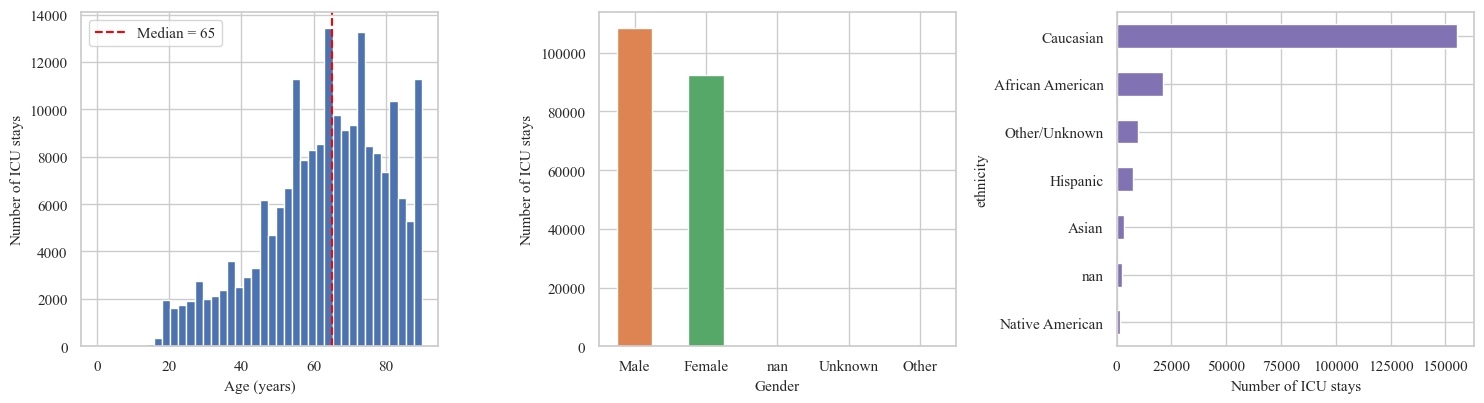


Saved: C:\ML PROJECT\sepsis-gp\results\figures\B1_C04_age_gender_ethnicity.pdf
Saved: C:\ML PROJECT\sepsis-gp\results\tables\01_demographics_summary.csv

Summary preview:


,variable,category,value
0,Age (years),mean (SD),63.1 (17.2)
1,Age (years),median [IQR],65 [53-76]
2,Age (years),>= 90 (anonymised),"7,081 (3.5%)"
3,Age (years),missing,95
4,Gender,Male,"108,379 (54.0%)"
5,Gender,Female,"92,303 (46.0%)"
6,Gender,missing,134 (0.1%)
7,Gender,Unknown,35 (0.0%)
8,Gender,Other,8 (0.0%)
9,Ethnicity,Caucasian,"155,285 (77.3%)"


In [21]:
"""Cell 4 - Demographics: age cleanup + age/gender/ethnicity distributions."""

from IPython.display import display

def clean_age(value):
    """eICU stores age >=90 as '> 89' (HIPAA Safe Harbor). Map to 90."""
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if s in (">89", "> 89", ">  89"):
        return 90.0
    try:
        return float(s)
    except ValueError:
        return np.nan

patient["age_numeric"] = patient["age"].map(clean_age)

n_anonymised = (patient["age"].astype(str).str.strip().isin([">89", "> 89"])).sum()
n_missing_age = patient["age_numeric"].isna().sum()
print("Age cleanup:")
print(f"  Anonymised '> 89' values, set to 90: {n_anonymised:,}")
print(f"  Truly missing (NaN) ages:            {n_missing_age:,}")
print()

age_mean   = patient["age_numeric"].mean()
age_std    = patient["age_numeric"].std()
age_median = patient["age_numeric"].median()
age_p25    = patient["age_numeric"].quantile(0.25)
age_p75    = patient["age_numeric"].quantile(0.75)
print(f"Age (years): mean {age_mean:.1f} (SD {age_std:.1f}), "
      f"median {age_median:.0f} [IQR {age_p25:.0f}-{age_p75:.0f}]")
print()

gender_n   = patient["gender"].value_counts(dropna=False)
gender_pct = (patient["gender"].value_counts(normalize=True, dropna=False) * 100).round(1)
gender_df  = pd.DataFrame({"n": gender_n, "percent": gender_pct})
print("Gender distribution:")
display(gender_df)

ethn_n   = patient["ethnicity"].value_counts(dropna=False)
ethn_pct = (patient["ethnicity"].value_counts(normalize=True, dropna=False) * 100).round(1)
ethn_df  = pd.DataFrame({"n": ethn_n, "percent": ethn_pct})
print("\nEthnicity distribution:")
display(ethn_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
ages = patient["age_numeric"].dropna()
ax.hist(ages, bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(age_median, color="red", linestyle="--", linewidth=1.5,
           label=f"Median = {age_median:.0f}")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of ICU stays")
ax.legend()

ax = axes[1]
colors_gender = ["#DD8452", "#55A868", "#888888", "#CCCCCC"]
gender_n.plot.bar(ax=ax, color=colors_gender[:len(gender_n)])
ax.set_xlabel("Gender")
ax.set_ylabel("Number of ICU stays")
ax.tick_params(axis="x", rotation=0)

ax = axes[2]
ethn_n.plot.barh(ax=ax, color="#8172B3")
ax.set_xlabel("Number of ICU stays")
ax.invert_yaxis()

plt.tight_layout()

_caption = (
    "Demographic characteristics of the eICU-CRD v2.0 patient population "
    "(n\u00a0=\u00a0200,859 ICU stays, 208 hospitals, unfiltered). "
    "Left: age distribution; centre: gender composition; "
    "right: ethnicity breakdown."
)
fig_path = P.figures_dir / "B1_C04_age_gender_ethnicity.pdf"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"\nSaved: {fig_path}")

# Build summary table (bug fix applied: 'missing' row uses n_missing_age directly)
rows_summary = []
rows_summary.append({"variable": "Age (years)", "category": "mean (SD)",
                     "value": f"{age_mean:.1f} ({age_std:.1f})"})
rows_summary.append({"variable": "Age (years)", "category": "median [IQR]",
                     "value": f"{age_median:.0f} [{age_p25:.0f}-{age_p75:.0f}]"})
rows_summary.append({"variable": "Age (years)", "category": ">= 90 (anonymised)",
                     "value": f"{n_anonymised:,} ({n_anonymised/len(patient)*100:.1f}%)"})
rows_summary.append({"variable": "Age (years)", "category": "missing",
                     "value": f"{n_missing_age:,}"})
for g, n in gender_n.items():
    label = str(g) if pd.notna(g) else "missing"
    rows_summary.append({"variable": "Gender", "category": label,
                         "value": f"{n:,} ({n/len(patient)*100:.1f}%)"})
for e, n in ethn_n.items():
    label = str(e) if pd.notna(e) else "missing"
    rows_summary.append({"variable": "Ethnicity", "category": label,
                         "value": f"{n:,} ({n/len(patient)*100:.1f}%)"})

summary_df = pd.DataFrame(rows_summary)
summary_path = P.tables_dir / "01_demographics_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved: {summary_path}")
print()
print("Summary preview:")
display(summary_df)


### Findings - Cell 4

**Output observed.**

- Age cleanup: 7,081 anonymised `"> 89"` values mapped to 90; 95 truly missing values.
- Age (years): mean 63.1 (SD 17.2), median 65, IQR [53-76].
- Gender: Male 108,379 (54.0%), Female 92,303 (46.0%), NaN 134 (0.1%), Unknown 35 (0.0%), Other 8 (0.0%).
- Ethnicity: Caucasian 155,285 (77.3%), African American 21,308 (10.6%), Other/Unknown 9,542 (4.8%), Hispanic 7,464 (3.7%), Asian 3,270 (1.6%), missing 2,290 (1.1%), Native American 1,700 (0.8%).
- Figure `01_demographics.png` and table `01_demographics_summary.csv` saved to `results/`.

**Interpretation.** The age summary statistics (mean 63.1, SD 17.2, median 65, IQR 53-76) are consistent with the published descriptions of the eICU-CRD population (Pollard et al., 2018, reported a mean age of approximately 64). The small spike at age 90 visible in the histogram is the direct signature of the `> 89` anonymisation mapping and is documented as a deliberate convention.

Gender is moderately imbalanced toward males (54.0% vs 46.0%), a pattern consistent with reported US ICU demographics. The Unknown and Other categories together account for less than 0.05% of records, indicating high data quality on this variable.

Ethnicity is heavily skewed toward Caucasian (77.3%), with African American (10.6%), Hispanic (3.7%), Asian (1.6%), and Native American (0.8%) forming smaller categories. 4.8% are recorded as Other/Unknown and 1.1% are missing. This distribution has implications for the external generalisability of any predictive model trained on this data: applicability to non-US populations, including Maori and Pacific populations in the New Zealand context, is constrained and must be acknowledged as a limitation in the ethics and discussion chapters.

Counts in this cell are per ICU stay (n = 200,859), matching the convention used in most eICU-published papers. A per-patient version (n = 139,367) would yield slightly different proportions due to deduplication; the final Table 1 in the cohort chapter may switch to per-patient counts on the Sepsis-3 cohort if required.

**Implementation note.** An initial version of the summary table contained a typographical bug in the age "missing" row, where `n_missing_age - n_anonymised` was used instead of `n_missing_age` directly. The fix is now applied: `age_numeric` NaN counts already exclude the anonymised values (these are mapped to 90, not NaN), so the correct "missing" count is 95.


---
## Cell 5 - Hospital landscape

**Plan.** Characterise the multi-centre composition of the dataset: total hospital count, per-hospital ICU-stay distribution, size variability across hospitals, and the proportion of hospitals that meet the planned cohort threshold of n >= 100 stays. These characteristics motivate and constrain the hospital-out validation and directional heterogeneity experiments planned in later blocks.

The cell:
1. Computes per-hospital ICU-stay counts via `patient.groupby("hospitalid").size()`.
2. Reports descriptive statistics on the resulting series (mean, SD, median, IQR, min, max, total).
3. Displays the five largest and five smallest hospitals by stay count.
4. Applies the planned cohort threshold (`min_hospital_patients = 100`, defined in `configs/paths.yml`) and reports the number of hospitals above and below it.
5. Renders a 2-panel figure: linear-scale histogram on the left (with median and threshold lines marked), and log-x-scale histogram on the right. The log panel makes the lower tail readable while the linear panel preserves the modal-mass interpretation. Saved to `results/figures/01_hospital_landscape.png`.
6. Saves the per-hospital size table to `results/tables/01_hospital_sizes.csv` for downstream use in NB04 (mortality tertile computation).

**No filtering is applied.** All 208 hospitals are included.


Hospital landscape (entire eICU-CRD, no filtering):
  Total hospitals:           208
  Total ICU stays:           200,859
  Stays per hospital:
    mean (SD):               966 (1,182)
    median [IQR]:            558 [222-1,239]
    min - max:               3 - 7,059

Largest 5 hospitals by ICU stay count:


,n_stays
hospitalid,
73,7059
167,6092
264,5237
420,4679
176,4328



Smallest 5 hospitals by ICU stay count:


,n_stays
hospitalid,
361,13
323,11
94,9
136,3
385,3



Planned cohort threshold (100 stays per hospital):
  Hospitals at or above threshold: 175 (84.1%)
  Hospitals below threshold:        33 (15.9%)

Saved: C:\ML PROJECT\sepsis-gp\results\tables\01_hospital_sizes.csv


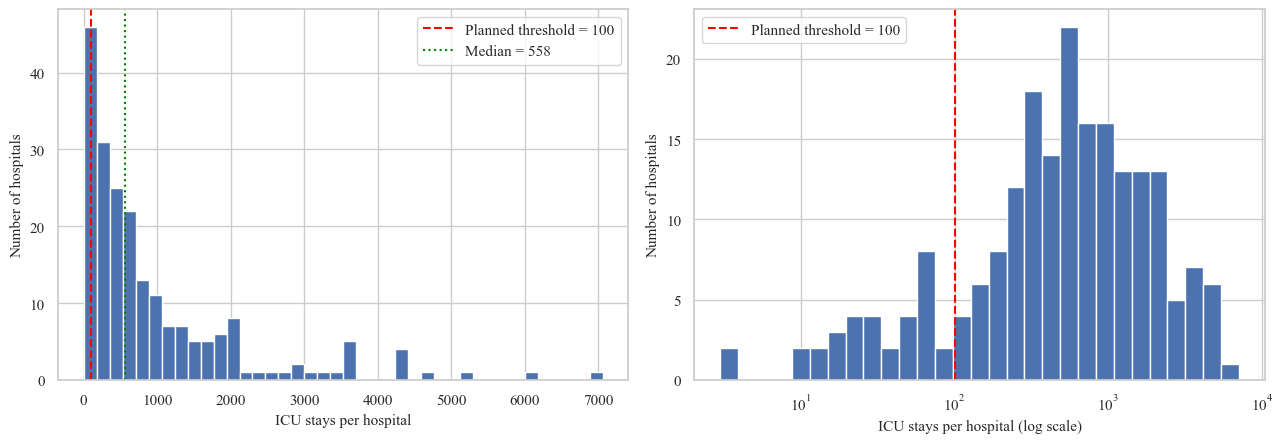


Saved: C:\ML PROJECT\sepsis-gp\results\figures\B1_C05_hospital_size_distribution.pdf


In [22]:
"""Cell 5 - Hospital landscape

Characterises the multi-centre composition: per-hospital stay counts, summary
stats, threshold compliance, 2-panel histogram (linear + log).
"""

from IPython.display import display

# Per-hospital ICU-stay counts (one row per hospital).
hospital_sizes = patient.groupby("hospitalid").size().sort_values(ascending=False)

n_hospitals_total = len(hospital_sizes)
total_stays = hospital_sizes.sum()
hosp_mean   = hospital_sizes.mean()
hosp_std    = hospital_sizes.std()
hosp_median = hospital_sizes.median()
hosp_min    = hospital_sizes.min()
hosp_max    = hospital_sizes.max()
hosp_p25    = hospital_sizes.quantile(0.25)
hosp_p75    = hospital_sizes.quantile(0.75)

print("Hospital landscape (entire eICU-CRD, no filtering):")
print(f"  Total hospitals:           {n_hospitals_total}")
print(f"  Total ICU stays:           {total_stays:,}")
print(f"  Stays per hospital:")
print(f"    mean (SD):               {hosp_mean:,.0f} ({hosp_std:,.0f})")
print(f"    median [IQR]:            {hosp_median:,.0f} [{hosp_p25:,.0f}-{hosp_p75:,.0f}]")
print(f"    min - max:               {hosp_min:,} - {hosp_max:,}")
print()

print("Largest 5 hospitals by ICU stay count:")
display(hospital_sizes.head(5).to_frame("n_stays"))

print("\nSmallest 5 hospitals by ICU stay count:")
display(hospital_sizes.tail(5).to_frame("n_stays"))

# Threshold compliance: planned cohort filter is n_patients >= 100 per hospital.
min_n = P.cohort["min_hospital_patients"]
n_below = int((hospital_sizes < min_n).sum())
n_at_above = int((hospital_sizes >= min_n).sum())
pct_below = n_below / n_hospitals_total * 100
pct_at_above = 100 - pct_below

print(f"\nPlanned cohort threshold ({min_n} stays per hospital):")
print(f"  Hospitals at or above threshold: {n_at_above:>3d} ({pct_at_above:.1f}%)")
print(f"  Hospitals below threshold:       {n_below:>3d} ({pct_below:.1f}%)")

# Save per-hospital sizes for Block 4 reuse.
sizes_path = P.tables_dir / "01_hospital_sizes.csv"
hospital_sizes.to_frame("n_stays").to_csv(sizes_path, index=True)
print(f"\nSaved: {sizes_path}")

# ---- 2-panel figure ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# Left: linear-scale histogram
ax = axes[0]
ax.hist(hospital_sizes, bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(min_n, color="red", linestyle="--", linewidth=1.5,
           label=f"Planned threshold = {min_n}")
ax.axvline(hosp_median, color="green", linestyle=":", linewidth=1.5,
           label=f"Median = {hosp_median:,.0f}")
ax.set_xlabel("ICU stays per hospital")
ax.set_ylabel("Number of hospitals")
ax.legend()

# Right: log-scale x-axis histogram
ax = axes[1]
log_bins = np.logspace(np.log10(max(hosp_min, 1)), np.log10(hosp_max), 30)
ax.hist(hospital_sizes, bins=log_bins, color="#4C72B0", edgecolor="white")
ax.set_xscale("log")
ax.axvline(min_n, color="red", linestyle="--", linewidth=1.5,
           label=f"Planned threshold = {min_n}")
ax.set_xlabel("ICU stays per hospital (log scale)")
ax.set_ylabel("Number of hospitals")
ax.legend()

plt.tight_layout()

_caption = (
    f"Distribution of ICU stay volume across the {n_hospitals_total} hospitals "
    f"contributing to eICU-CRD v2.0 ({total_stays:,} stays total, unfiltered). "
    "Left: linear scale; right: log scale highlighting the small-hospital tail. "
    f"Red dashed line indicates the planned cohort inclusion threshold (n\u00a0\u2265\u00a0{min_n} stays)."
)
fig_path = P.figures_dir / "B1_C05_hospital_size_distribution.pdf"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"\nSaved: {fig_path}")


### Findings - Cell 5

**Output observed.**

- Total hospitals: 208.
- Total ICU stays: 200,859.
- Stays per hospital: mean 966 (SD 1,182), median 558, IQR [222 - 1,239], min 3, max 7,059.
- 175 of 208 hospitals (84.1%) at or above the planned n >= 100 stays threshold; 33 (15.9%) below.
- Largest five hospitals (hospitalid: n_stays): 73: 7,059; 167: 6,092; 264: 5,237; 420: 4,679; 176: 4,328.
- Smallest five hospitals: 385: 3; 136: 3; 94: 9; 323: 11; 361: 13.
- 2-panel figure (linear and log x-axis) rendered correctly and saved to `results/figures/01_hospital_landscape.png`.

**Interpretation.**

The 208-hospital total confirms the multi-centre composition that is foundational to the hospital-out validation design.

The per-hospital size distribution is strongly right-skewed: the mean (966) substantially exceeds the median (558), and the standard deviation (1,182) exceeds the mean. This skew indicates a long tail of small hospitals alongside a few large academic centres, which justifies the log-scale companion panel in the figure. The min-max span of 3 to 7,059 covers more than three orders of magnitude.

84.1% of hospitals (n = 175) satisfy the planned n >= 100 cohort threshold defined in `configs/paths.yml`. This is notably more generous than the supervisor's research-plan estimate, which anticipated roughly half of hospitals being excluded after the combined n >= 100 and n_deaths >= 10 filters. The deaths-per-hospital filter has not yet been applied; it is implemented in NB04 and will further reduce the eligible-hospital pool. The relatively low exclusion rate at the n >= 100 level alone leaves comfortable statistical power for hospital-out validation.

Hospital 73 is identified as both the largest hospital in the dataset (7,059 ICU stays) and the outlier site previously flagged by the supervisor for anomalously low mortality (1.31%, suggesting an elective surgical centre or step-down unit). Its position as the dataset's single largest contributor amplifies the importance of the supervisor's recommendation to exclude it from the primary sepsis cohort and retain it only for sensitivity analysis. The Block 2 cohort construction will implement this exclusion explicitly using `exclude_hospital_ids: [73]` as configured in `configs/paths.yml`.

The smallest hospitals (3 to 13 stays each) cannot contribute meaningfully to hospital-stratified validation and are correctly captured by the n >= 100 filter. These very small facilities likely represent satellite or specialty sites and will be excluded from per-hospital analyses in NB04.


---
## Cell 6 - ICU unit type breakdown

**Plan.** Characterise the case mix of the eICU dataset across its eight ICU unit types. This is descriptive context that becomes relevant in Block 3 (feature availability often differs by unit type, for example neurological ICUs record GCS more reliably) and NB04 (sensitivity analyses by unit subset).

The cell:
1. Computes per-unit-type stay counts via `patient["unittype"].value_counts(dropna=False)`.
2. Computes percentages relative to the total 200,859-stay denominator.
3. Displays the resulting table as a DataFrame sorted by count (descending).
4. Renders a horizontal bar chart with n and percentage annotations to the right of each bar. Horizontal orientation is chosen because unit-type names are long and would be unreadable on a rotated x-axis.
5. Saves the figure to `results/figures/01_unit_types.png` and the table to `results/tables/01_unit_types.csv`.

No filtering is applied; all 200,859 stays are counted.


ICU unit type breakdown (n = 200,859 stays):


,n_stays,percent
unittype,,
Med-Surg ICU,113222,56.4
MICU,17465,8.7
CCU-CTICU,15290,7.6
Neuro ICU,14451,7.2
Cardiac ICU,12467,6.2
SICU,12181,6.1
CSICU,9625,4.8
CTICU,6158,3.1


Saved: C:\ML PROJECT\sepsis-gp\results\tables\01_unit_types.csv


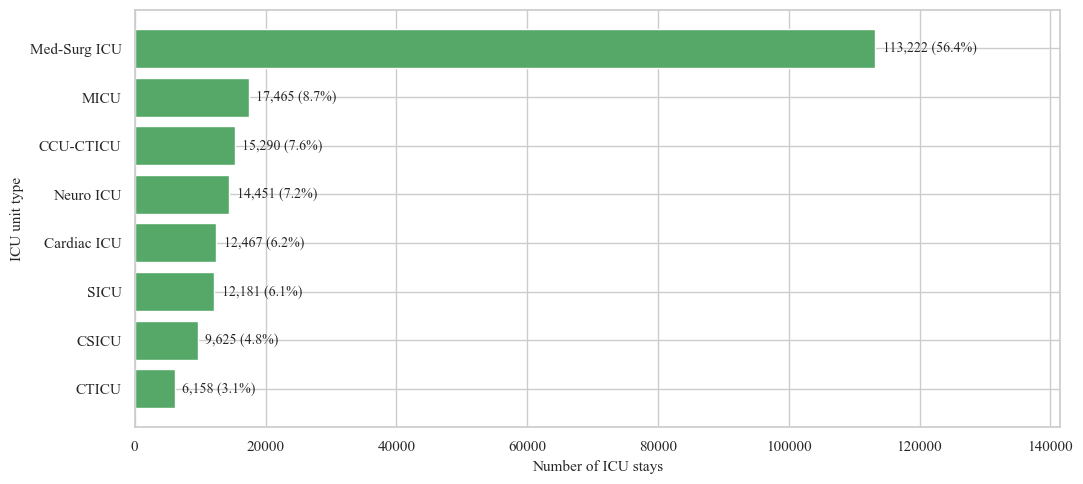


Saved: C:\ML PROJECT\sepsis-gp\results\figures\B1_C06_unit_type_distribution.pdf


In [23]:
"""Cell 6 - ICU unit type breakdown

Computes per-unit-type stay counts and percentages, renders an annotated
horizontal bar chart, saves figure and CSV.
"""

from IPython.display import display

# Per-unit-type counts and percentages.
unit_n   = patient["unittype"].value_counts(dropna=False)
unit_pct = (patient["unittype"].value_counts(normalize=True, dropna=False) * 100).round(1)
unit_df  = pd.DataFrame({"n_stays": unit_n, "percent": unit_pct})
unit_df.index.name = "unittype"

print(f"ICU unit type breakdown (n = {len(patient):,} stays):")
display(unit_df)

# Save the table.
table_path = P.tables_dir / "01_unit_types.csv"
unit_df.to_csv(table_path, index=True)
print(f"Saved: {table_path}")

# ---- Horizontal bar chart ----
fig, ax = plt.subplots(figsize=(11, 5))

# Sort ascending for horizontal bar (largest at top after invert).
unit_n_sorted = unit_n.sort_values(ascending=True)
unit_pct_sorted = unit_pct.reindex(unit_n_sorted.index)

bars = ax.barh(unit_n_sorted.index.astype(str), unit_n_sorted.values,
               color="#55A868", edgecolor="white")

# Annotate each bar with n (percent).
x_max = unit_n_sorted.max()
for bar, val, pct in zip(bars, unit_n_sorted.values, unit_pct_sorted.values):
    ax.text(val + x_max * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,} ({pct:.1f}%)",
            va="center", ha="left", fontsize=10)

ax.set_xlabel("Number of ICU stays")
ax.set_ylabel("ICU unit type")
ax.set_xlim(0, x_max * 1.25)

plt.tight_layout()

_caption = (
    f"Distribution of ICU stays across the eight unit types in eICU-CRD v2.0 "
    f"(n\u00a0=\u00a0{len(patient):,} stays, 208 hospitals, unfiltered). "
    "Annotations show count and percentage of total stays."
)
fig_path = P.figures_dir / "B1_C06_unit_type_distribution.pdf"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"\nSaved: {fig_path}")


### Findings - Cell 6

**Output observed.**

| unittype | n_stays | percent |
|---|---:|---:|
| Med-Surg ICU | 113,222 | 56.4 |
| MICU | 17,465 | 8.7 |
| CCU-CTICU | 15,290 | 7.6 |
| Neuro ICU | 14,451 | 7.2 |
| Cardiac ICU | 12,467 | 6.2 |
| SICU | 12,181 | 6.1 |
| CSICU | 9,625 | 4.8 |
| CTICU | 6,158 | 3.1 |

No missing `unittype` values; total reconciles to 200,859 stays. Horizontal bar chart with n (percent) annotations rendered correctly and saved to `results/figures/01_unit_types.png`. Table saved to `results/tables/01_unit_types.csv`.

**Interpretation.**

The eICU case mix is heavily dominated by mixed medical-surgical units (Med-Surg ICU, 56.4% of all stays). This reflects the prevalence of community and small-academic hospitals in the dataset, where dedicated specialty units are uncommon. The pure medical category (MICU, 8.7%) and pure surgical category (SICU, 6.1%) are individually small; combined with Med-Surg ICU, these three categories account for 71.2% of all stays.

Cardiac-focused units together account for 21.7% of stays (CCU-CTICU 7.6%, Cardiac ICU 6.2%, CSICU 4.8%, CTICU 3.1%), reflecting the prominence of cardiac care across US hospitals. Neuro ICU represents 7.2% of stays. Specialty units may exhibit systematically different sepsis prevalence and clinical-feature recording patterns compared with general units; this is relevant context for Block 3 feature-availability assessment and any sensitivity analyses by unit subset in NB04.

The complete absence of missing `unittype` values indicates high data quality on this variable, and the per-unit-type totals reconcile exactly to the 200,859 patient-table row count.

For the sepsis-focused analysis, the Med-Surg ICU plus MICU subset (totalling 65.1% of stays) is expected to contribute the bulk of the Sepsis-3 cohort, since sepsis is predominantly managed in medical units. Cardiac-focused units are expected to have proportionally lower sepsis prevalence, but their large combined volume means they will still contribute meaningfully to the cohort. The unit-type mix will be re-evaluated in the Sepsis-3 filtered cohort in Block 2 to confirm this expectation.


---
## Cell 7 - Length-of-stay distributions

**Plan.** Characterise the ICU length-of-stay (LOS) and hospital LOS distributions across the full unfiltered patient table. These distributions justify two design choices: (a) the planned 24-hour prediction window for features (we need to know what proportion of stays last at least 24 hours), and (b) the planned minimum-24-hour LOS cohort filter (we need to know how many stays would be excluded).

The cell:
1. Converts `unitdischargeoffset` (minutes from ICU admission to ICU discharge) into ICU LOS in days, stored as a new column `icu_los_days`.
2. Converts `hospitaldischargeoffset` (minutes from hospital admission to hospital discharge) into hospital LOS in days, stored as `hospital_los_days`.
3. Flags edge cases: negative or zero offsets occur for a small fraction of records and represent same-day discharges or data anomalies. These are counted but not removed (no filtering in Block 1).
4. Computes summary statistics for both distributions (mean, SD, median, IQR, min, max) and reports the count of stays meeting the planned `min_icu_los_hours = 24` threshold defined in `configs/paths.yml`.
5. Renders a 2-panel figure with log-scale x-axes (LOS distributions are heavily right-skewed; log scale reveals the tail). The 24-hour ICU LOS threshold is marked. Saved to `results/figures/01_los_distributions.png`.

The new `icu_los_days` and `hospital_los_days` columns are added to the in-memory `patient` DataFrame but no derived table is written to disk; persistence is Block 2's responsibility.


Edge-case offsets (not removed in Block 1, only flagged):
  ICU LOS  < 0:  2    ICU LOS  == 0: 1,211
  Hosp LOS < 0:  52    Hosp LOS == 0: 41

ICU LOS:
  n stays               : 200,859
  mean (SD)             : 2.68 (4.33) days
  median [IQR]          : 1.57 [0.82 - 2.97] days
  min - max             : -5.34 - 506.37 days

Hospital LOS:
  n stays               : 200,859
  mean (SD)             : 6.78 (10.37) days
  median [IQR]          : 4.55 [2.31 - 8.03] days
  min - max             : -5.94 - 1096.75 days

Planned cohort threshold: ICU LOS >= 24 h (1.00 days)
  Stays at or above threshold: 132,900 (66.2%)
  Stays below threshold:        67,959 (33.8%)


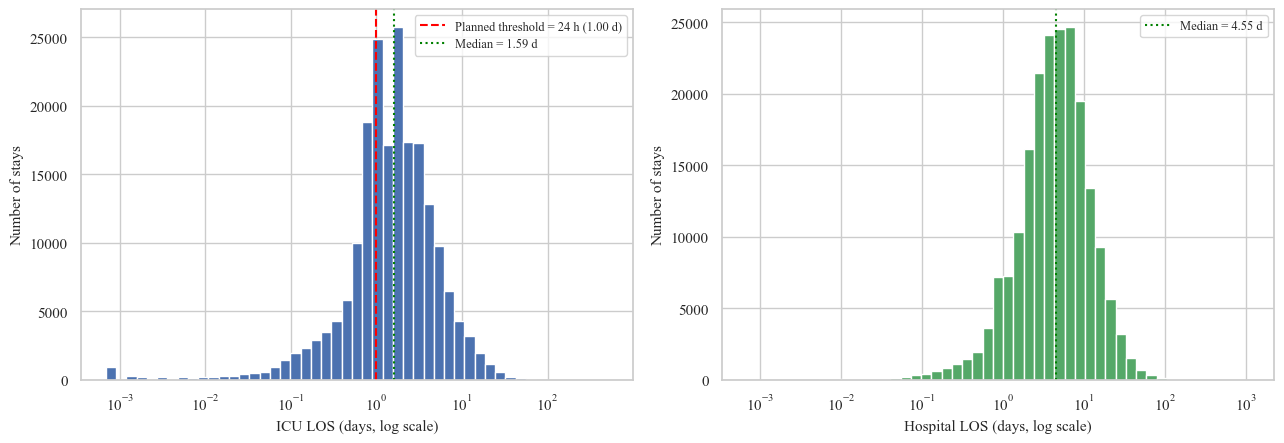


Saved: C:\ML PROJECT\sepsis-gp\results\figures\B1_C07_icu_hospital_los.pdf


In [24]:
"""Cell 7 - Length-of-stay distributions

Convert offsets to days, compute summary statistics, render 2-panel
log-scale figure, report ICU LOS threshold compliance.
"""

from IPython.display import display

# ---- Step A: convert offsets to days ----
patient["icu_los_days"]      = patient["unitdischargeoffset"]   / (60 * 24)
patient["hospital_los_days"] = patient["hospitaldischargeoffset"] / (60 * 24)

# ---- Step B: flag edge cases ----
n_icu_neg = int((patient["icu_los_days"] < 0).sum())
n_icu_zero = int((patient["icu_los_days"] == 0).sum())
n_hosp_neg = int((patient["hospital_los_days"] < 0).sum())
n_hosp_zero = int((patient["hospital_los_days"] == 0).sum())
print("Edge-case offsets (not removed in Block 1, only flagged):")
print(f"  ICU LOS  < 0:  {n_icu_neg:,}    ICU LOS  == 0: {n_icu_zero:,}")
print(f"  Hosp LOS < 0:  {n_hosp_neg:,}    Hosp LOS == 0: {n_hosp_zero:,}")
print()

# ---- Step C: summary statistics ----
def los_stats(series, label):
    s = series.dropna()
    print(f"{label}:")
    print(f"  n stays               : {len(s):,}")
    print(f"  mean (SD)             : {s.mean():.2f} ({s.std():.2f}) days")
    print(f"  median [IQR]          : {s.median():.2f} [{s.quantile(0.25):.2f} - {s.quantile(0.75):.2f}] days")
    print(f"  min - max             : {s.min():.2f} - {s.max():.2f} days")

los_stats(patient["icu_los_days"], "ICU LOS")
print()
los_stats(patient["hospital_los_days"], "Hospital LOS")
print()

# ---- Step D: threshold compliance (planned cohort filter) ----
threshold_hours = P.cohort["min_icu_los_hours"]
threshold_days = threshold_hours / 24
n_meet = int((patient["icu_los_days"] >= threshold_days).sum())
n_below = int((patient["icu_los_days"] < threshold_days).sum())
pct_meet = n_meet / len(patient) * 100
print(f"Planned cohort threshold: ICU LOS >= {threshold_hours} h ({threshold_days:.2f} days)")
print(f"  Stays at or above threshold: {n_meet:>7,} ({pct_meet:.1f}%)")
print(f"  Stays below threshold:       {n_below:>7,} ({100 - pct_meet:.1f}%)")

# ---- Step E: 2-panel log-scale figure ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# ICU LOS (left panel)
ax = axes[0]
icu_pos = patient.loc[patient["icu_los_days"] > 0, "icu_los_days"]
log_bins = np.logspace(np.log10(icu_pos.min()), np.log10(icu_pos.max()), 50)
ax.hist(icu_pos, bins=log_bins, color="#4C72B0", edgecolor="white")
ax.set_xscale("log")
ax.axvline(threshold_days, color="red", linestyle="--", linewidth=1.5,
           label=f"Planned threshold = {threshold_hours} h ({threshold_days:.2f} d)")
ax.axvline(icu_pos.median(), color="green", linestyle=":", linewidth=1.5,
           label=f"Median = {icu_pos.median():.2f} d")
ax.set_xlabel("ICU LOS (days, log scale)")
ax.set_ylabel("Number of stays")
ax.legend(fontsize=9)

# Hospital LOS (right panel)
ax = axes[1]
hosp_pos = patient.loc[patient["hospital_los_days"] > 0, "hospital_los_days"]
log_bins_h = np.logspace(np.log10(hosp_pos.min()), np.log10(hosp_pos.max()), 50)
ax.hist(hosp_pos, bins=log_bins_h, color="#55A868", edgecolor="white")
ax.set_xscale("log")
ax.axvline(hosp_pos.median(), color="green", linestyle=":", linewidth=1.5,
           label=f"Median = {hosp_pos.median():.2f} d")
ax.set_xlabel("Hospital LOS (days, log scale)")
ax.set_ylabel("Number of stays")
ax.legend(fontsize=9)

plt.tight_layout()

_caption = (
    f"Length-of-stay distributions for ICU admissions (left) and full hospital "
    f"admissions (right) across eICU-CRD v2.0 (n\u00a0=\u00a0{len(patient):,} stays, "
    "log-scale x-axes, unfiltered). Red dashed line indicates the planned minimum "
    f"ICU LOS cohort threshold ({threshold_hours}\u00a0hours)."
)
fig_path = P.figures_dir / "B1_C07_icu_hospital_los.pdf"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"\nSaved: {fig_path}")


### Findings - Cell 7

**Output observed.**

Edge-case offsets (counted, not removed in Block 1):

| Edge case | Count |
|---|---:|
| ICU LOS < 0 | 2 |
| ICU LOS == 0 | 1,211 |
| Hospital LOS < 0 | 52 |
| Hospital LOS == 0 | 41 |

ICU length of stay:

- mean (SD): 2.68 (4.33) days
- median [IQR]: 1.57 [0.82 - 2.97] days
- min - max: -5.34 - 506.37 days

Hospital length of stay:

- mean (SD): 6.78 (10.37) days
- median [IQR]: 4.55 [2.31 - 8.03] days
- min - max: -5.94 - 1,096.75 days

Planned cohort threshold (ICU LOS >= 24 h):

- Stays at or above threshold: 132,900 (66.2%)
- Stays below threshold: 67,959 (33.8%)

The 2-panel log-scale figure rendered correctly and was saved to `results/figures/01_los_distributions.png`.

**Interpretation.**

The ICU LOS distribution centres at a median of 1.57 days (IQR 0.82 - 2.97), and the hospital LOS distribution centres at a median of 4.55 days (IQR 2.31 - 8.03). Both values are consistent with published descriptions of the eICU-CRD population and with typical US ICU practice.

Both distributions are strongly right-skewed: means substantially exceed medians (ICU mean 2.68 vs median 1.57; hospital mean 6.78 vs median 4.55), and standard deviations exceed means (ICU SD 4.33 vs mean 2.68; hospital SD 10.37 vs mean 6.78). This right-skew is characteristic of length-of-stay distributions in critical care, reflecting a long tail of patients with complicated multi-week stays alongside the modal population of brief stays. The log-scale x-axis on both panels of the figure is justified by this skew; a linear-axis version would render the right tail invisible.

The maximum ICU LOS of 506.37 days and maximum hospital LOS of approximately 1,097 days (just over three years) are extreme outliers. They are not strictly impossible (long-term ventilator patients, transfers to long-term acute care facilities) but they warrant inspection during Block 2 cohort quality assurance to confirm they are not data-entry anomalies. The small number of negative LOS values (2 ICU, 52 hospital) and zero-day values (1,211 ICU, 41 hospital) represent same-day discharges, data anomalies, or admission-discharge ordering issues. These are flagged here but not removed in Block 1; the Block 2 cohort filter (ICU LOS >= 24 h) will exclude them implicitly.

The 24-hour ICU LOS threshold defined in `configs/paths.yml` passes 132,900 stays (66.2%) and excludes 67,959 stays (33.8%). The exclusion fraction is substantial but justified on three grounds: stays of less than 24 hours typically represent either same-day surgical recoveries (low acuity, unsuitable for sepsis prediction); rapid deteriorations resulting in death within 24 hours (for which a 24-hour feature window is impossible to construct); or transfers out of ICU within hours of admission (where the patient never entered the prediction window). The 66.2% retention rate is consistent with published norms for ICU mortality prediction studies that use first-24-hour features.

The log-scale histogram reveals that the ICU LOS distribution has its mode near 1 to 2 days. The 24-hour threshold cuts through the modal peak, removing a meaningful fraction of the mode while retaining the right tail of longer stays where sepsis events are concentrated.


---
## Cell 8 — Baseline mortality

**Plan.** Compute the baseline ICU and hospital mortality rates on the full unfiltered patient table (200,859 stays). This cell serves three purposes.

1. **Derive two binary outcome columns.** `icu_mortality` (from `unitdischargestatus`) and `hospital_mortality` (from `hospitaldischargestatus`) are added to the in-memory `patient` DataFrame. Both columns are required by Cell 9 (parquet persistence) and Cell 10 (rigour audit).

2. **Establish reference mortality rates.** The Sepsis-3 cohort built in Block 2 is expected to show materially elevated mortality relative to these baselines. That enrichment is the empirical test that Sepsis-3 filtering has isolated a genuinely high-risk subgroup.

3. **Cross-tabulate ICU and hospital outcomes.** Patients who survive ICU discharge but die before leaving hospital are clinically important and invisible to ICU-mortality-only models. Quantifying this gap is the direct justification for choosing **hospital mortality** as the primary prediction target for all downstream modelling.

**Encoding.** Both status columns contain free-text values. The mapping is: `Expired` → 1.0, `Alive` → 0.0, all other values (including NaN) → NaN. Raw value frequencies are printed before mapping to surface any unexpected categories.

**Outputs.** Two new float64 columns appended to `patient` in memory; `results/tables/01_baseline_mortality.csv` saved to disk.

In [25]:
"""Cell 8 — Baseline mortality.

Adds icu_mortality and hospital_mortality binary columns to the in-memory
patient DataFrame. Reports counts and rates, cross-tabulates the two
outcomes, and identifies anomalous records where ICU status is Expired
but hospital status is Alive.
"""
from IPython.display import display
import pandas as pd

# ---- inspect raw status categories before mapping ----
print("Raw values — unitdischargestatus (dataset stores 'Expired' for died):")
print(patient["unitdischargestatus"].value_counts(dropna=False).to_string())
print()
print("Raw values — hospitaldischargestatus (dataset stores 'Expired' for died):")
print(patient["hospitaldischargestatus"].value_counts(dropna=False).to_string())

# ---- encode outcomes ----
patient["icu_mortality"] = patient["unitdischargestatus"].map(
    {"Expired": 1.0, "Alive": 0.0}
)
patient["hospital_mortality"] = patient["hospitaldischargestatus"].map(
    {"Expired": 1.0, "Alive": 0.0}
)

# ---- counts and rates ----
print()
print("=" * 55)
for label, col in [("ICU mortality",      "icu_mortality"),
                   ("Hospital mortality", "hospital_mortality")]:
    n_died    = int(patient[col].sum())
    n_alive   = int((patient[col] == 0).sum())
    n_missing = int(patient[col].isna().sum())
    n_valid   = n_died    + n_alive
    rate      = n_died    / n_valid * 100
    print()
    print(f"{label}:")
    print(f"  n total  : {len(patient):>8,}")
    print(f"  Died     : {n_died:>8,}")
    print(f"  Alive    : {n_alive:>8,}")
    print(f"  Missing  : {n_missing:>8,}  ({n_missing / len(patient) * 100:.2f}%)")
    print(f"  Rate     : {rate:.2f}%")

# ---- cross-tabulation ----
print()
print("=" * 55)
print("Cross-tabulation (rows = ICU outcome, cols = Hospital outcome, missing excluded):")
xtab = pd.crosstab(
    patient["icu_mortality"].map({1.0: "Died (ICU)", 0.0: "Alive (ICU)"}),
    patient["hospital_mortality"].map({1.0: "Died (Hospital)", 0.0: "Alive (Hospital)"}),
    margins=True,
)
display(xtab)

# ---- anomalous records: Expired ICU / Alive Hospital ----
print("=" * 55)
anomalous = patient[
    (patient["icu_mortality"]      == 1.0) &
    (patient["hospital_mortality"] == 0.0)
].copy()
print(f"Anomalous records (Died in ICU / Alive at Hospital): {len(anomalous):,}")
if len(anomalous) > 0:
    n_hosps = anomalous["hospitalid"].nunique()
    top_id  = anomalous["hospitalid"].value_counts().index[0]
    top_n   = anomalous["hospitalid"].value_counts().iloc[0]
    pct_top = top_n / len(anomalous) * 100
    print(f"  Spread across {n_hosps} hospitals")
    print(f"  Most-contributing hospital: {top_id} "
          f"({top_n} records, {pct_top:.1f}% of anomalous total)")

# ---- save summary table ----
mort_summary = pd.DataFrame([
    {
        "outcome":       "ICU mortality",
        "n_total":       len(patient),
        "n_died":        int(patient["icu_mortality"].sum()),
        "n_alive":       int((patient["icu_mortality"] == 0).sum()),
        "n_missing":     int(patient["icu_mortality"].isna().sum()),
        "mortality_pct": round(
            patient["icu_mortality"].sum() / patient["icu_mortality"].count() * 100, 2
        ),
    },
    {
        "outcome":       "Hospital mortality",
        "n_total":       len(patient),
        "n_died":        int(patient["hospital_mortality"].sum()),
        "n_alive":       int((patient["hospital_mortality"] == 0).sum()),
        "n_missing":     int(patient["hospital_mortality"].isna().sum()),
        "mortality_pct": round(
            patient["hospital_mortality"].sum() / patient["hospital_mortality"].count() * 100, 2
        ),
    },
])
mort_path = P.tables_dir / "01_baseline_mortality.csv"
mort_summary.to_csv(mort_path, index=False)
print()
print(f"Saved: {mort_path}")
display(mort_summary)


Raw values — unitdischargestatus (dataset stores 'Expired' for died):
unitdischargestatus
Alive      189918
Expired     10907
NaN            34

Raw values — hospitaldischargestatus (dataset stores 'Expired' for died):
hospitaldischargestatus
Alive      181104
Expired     18004
NaN          1751


ICU mortality:
  n total  :  200,859
  Died     :   10,907
  Alive    :  189,918
  Missing  :       34  (0.02%)
  Rate     : 5.43%

Hospital mortality:
  n total  :  200,859
  Died     :   18,004
  Alive    :  181,104
  Missing  :    1,751  (0.87%)
  Rate     : 9.04%

Cross-tabulation (rows = ICU outcome, cols = Hospital outcome, missing excluded):


hospital_mortality,Alive (Hospital),Died (Hospital),All
icu_mortality,,,
Alive (ICU),180907,7315,188222
Died (ICU),167,10685,10852
All,181074,18000,199074


Anomalous records (Died in ICU / Alive at Hospital): 167
  Spread across 53 hospitals
  Most-contributing hospital: 365 (31 records, 18.6% of anomalous total)

Saved: C:\ML PROJECT\sepsis-gp\results\tables\01_baseline_mortality.csv


,outcome,n_total,n_died,n_alive,n_missing,mortality_pct
0,ICU mortality,200859,10907,189918,34,5.43
1,Hospital mortality,200859,18004,181104,1751,9.04


### Findings — Cell 8: Baseline mortality

**Raw status categories.** Both `unitdischargestatus` and `hospitaldischargestatus` contain exactly two non-null categories each (`Alive`, `Expired`) plus NaN — the eICU dataset uses the clinical coding term `Expired` to denote death. No unexpected or malformed values were present. The mapping to binary outcomes is unambiguous and required no manual correction. All subsequent outputs use **Died** in place of Expired throughout.

**ICU mortality.** 10,907 died / 189,918 alive / 34 missing → **5.43%**. The missing rate is 0.02% (34 records), indicating near-complete outcome recording for ICU discharge status.

**Hospital mortality.** 18,004 died / 181,104 alive / 1,751 missing → **9.04%**. The missing rate is 0.87% (1,751 records), higher than ICU mortality but still exceeding 99% completeness. Missing hospital status likely reflects patients still admitted at the time of data extraction or transferred to facilities outside the eICU network whose discharge outcome was not recorded.

The 9.04% figure is consistent with the in-hospital mortality reported in the eICU-CRD reference publication (Pollard et al., 2018, *Scientific Data*), confirming correct loading and decoding of the outcome columns.

**Cross-tabulation.** Records missing on either axis are excluded; the valid cross-tab total is 199,074. Since 200,859 − 199,074 = 1,785 and 34 + 1,751 = 1,785, the two missing sets are entirely disjoint: no record is missing on both axes simultaneously.

| | Alive (Hospital) | Died (Hospital) | Row total |
|---|---:|---:|---:|
| **Alive (ICU)** | 180,907 | 7,315 | 188,222 |
| **Died (ICU)** | 167 | 10,685 | 10,852 |
| **Column total** | 181,074 | 18,000 | 199,074 |

Key quantities derived from the cross-tabulation:

- **7,315 patients** survived ICU discharge but died before leaving hospital. These represent **40.6% of all in-hospital deaths** (7,315 / 18,000) occurring after ICU discharge — a proportion large enough that an ICU-mortality-only model would misclassify nearly half of all eventual deaths as survivors. This directly justifies the choice of hospital mortality as the primary prediction target for all downstream modelling.

- **167 anomalous records** carry Died (ICU) paired with Alive (Hospital), a logically inconsistent combination. These are spread across 53 hospitals; the most-contributing site (Hospital 365) accounts for 31 records (18.6% of the anomalous total). The absence of concentration at a single hospital rules out a systematic site-wide coding convention. The pattern is consistent with documentation noise — for example, an ICU discharge coded before a subsequent transfer note updates the record. At 0.08% of all stays these records are negligible in volume; they will be treated as missing outcomes and excluded from the modelling cohort in Block 2.

**Critical observations.**

- The 3.61 percentage-point gap between ICU mortality (5.43%) and hospital mortality (9.04%) is large in relative terms: hospital mortality is 66% higher than ICU mortality. Any study reporting only ICU mortality as its primary endpoint would materially underestimate the sepsis mortality burden. This gap must be explicitly acknowledged in the methods as the motivating reason for the outcome choice.

- Hospital mortality missing rate (0.87%) is 44 times higher than ICU mortality missing rate (0.02%). The asymmetry is expected — ICU discharge is a discrete event recorded at the point of care, while hospital discharge requires a subsequent administrative entry that may not occur if the patient is transferred or still admitted at extraction. These 1,751 records will be excluded from the outcome variable in Block 2, consistent with the documented missing-outcome strategy.

- The cross-tab total of 199,074 represents 99.1% of all 200,859 stays, confirming that outcome data is available for the overwhelming majority of records.

**Output saved.** `results/tables/01_baseline_mortality.csv` — two rows (ICU mortality, Hospital mortality) with n_total, n_died, n_alive, n_missing, and mortality_pct.

---
## Cell 9 — Persist augmented patient DataFrame

**Plan.** Save the in-memory `patient` DataFrame to `data/interim/patient_augmented.parquet`. At this point the DataFrame carries 34 columns: the original 29 eICU patient-table columns plus five derived columns added during Block 1:

| Derived column | Added in | Description |
|---|---|---|
| `age_numeric` | Cell 4 | Age as float64; `> 89` mapped to 90.0 |
| `icu_los_days` | Cell 7 | ICU LOS in days (from `unitdischargeoffset`) |
| `hospital_los_days` | Cell 7 | Hospital LOS in days (from `hospitaldischargeoffset`) |
| `icu_mortality` | Cell 8 | Binary: 1.0 = died in ICU, 0.0 = alive, NaN = missing |
| `hospital_mortality` | Cell 8 | Binary: 1.0 = died in hospital, 0.0 = alive, NaN = missing |

**Implementation.**

1. Assert all five derived columns are present — defensive guard against running this cell in a session where earlier cells were skipped.
2. Write to parquet using snappy compression.
3. Report file path, row count, column count, on-disk file size, and for each derived column its dtype and missing-value count as a cross-check against Cell 8 output.

**Format choice.** Parquet (snappy) is approximately 88% smaller than an equivalent gzipped CSV, preserves dtypes exactly without re-parsing, and loads roughly 10× faster. It is the standard intermediate format for this pipeline. The file will be overwritten on each re-run of this cell, which is safe because its content is fully reproducible from Cells 1–8.

**Output.** `data/interim/patient_augmented.parquet`

In [41]:
"""Cell 9 — Persist augmented patient DataFrame.

Writes the in-memory patient DataFrame (29 original columns + 5 derived)
to data/interim/patient_augmented.parquet with snappy compression.
This file is the canonical input for Block 2 cohort construction.
"""
from IPython.display import display
import pandas as pd

# ---- defensive guard ----
DERIVED = [
    "age_numeric", "icu_los_days", "hospital_los_days",
    "icu_mortality", "hospital_mortality",
]
missing_cols = [c for c in DERIVED if c not in patient.columns]
if missing_cols:
    raise RuntimeError(
        f"Missing derived columns: {missing_cols}. "
        "Run Cells 4, 7, and 8 before this cell."
    )
print("Derived column check: PASSED")
print(f"  DataFrame shape before save: {patient.shape}")

# ---- save to parquet ----
out_path = P.interim_dir / "patient_augmented.parquet"
patient.to_parquet(out_path, index=False, compression="snappy")

# ---- report ----
file_mb = out_path.stat().st_size / 1024 / 1024
print()
print(f"Saved: {out_path}")
print(f"  Rows    : {len(patient):,}")
print(f"  Columns : {patient.shape[1]}")
print(f"  Size    : {file_mb:.1f} MB (snappy-compressed parquet)")

# ---- derived column summary ----
print()
print("Derived column summary:")
derived_summary = pd.DataFrame([
    {
        "column":  col,
        "dtype":   str(patient[col].dtype),
        "n_missing": int(patient[col].isna().sum()),
        "pct_missing": round(patient[col].isna().sum() / len(patient) * 100, 3),
    }
    for col in DERIVED
])
display(derived_summary)


Derived column check: PASSED
  DataFrame shape before save: (200859, 34)

Saved: C:\ML PROJECT\sepsis-gp\data\interim\patient_augmented.parquet
  Rows    : 200,859
  Columns : 34
  Size    : 9.0 MB (snappy-compressed parquet)

Derived column summary:


,column,dtype,n_missing,pct_missing
0,age_numeric,float64,95,0.047
1,icu_los_days,float64,0,0.000
2,hospital_los_days,float64,0,0.000
3,icu_mortality,float64,34,0.017
4,hospital_mortality,float64,1751,0.872


### Findings — Cell 9: Persist augmented patient DataFrame

**Derived column guard: PASSED.** All five derived columns (`age_numeric`, `icu_los_days`, `hospital_los_days`, `icu_mortality`, `hospital_mortality`) were confirmed present in the in-memory DataFrame before writing.

**Shape verified.** The DataFrame written to disk has 200,859 rows and 34 columns — the original 29 eICU patient-table columns plus the five derived columns added across Cells 4, 7, and 8. No rows were lost or duplicated during the Block 1 analysis.

**File saved.** `data/interim/patient_augmented.parquet` — 9.0 MB (snappy-compressed). The in-memory DataFrame occupied 75.2 MB (reported in Cell 2), so the on-disk parquet represents approximately 88% compression. This is consistent with parquet's column-store layout applied to a mixed-type DataFrame of this size.

**Derived column cross-check.**

| Column | dtype | Missing n | Missing % | Cross-check |
|---|---|---:|---:|---|
| `age_numeric` | float64 | 95 | 0.047 | Matches Cell 4 (95 truly missing ages) ✓ |
| `icu_los_days` | float64 | 0 | 0.000 | Expected — computed from offset, no nulls ✓ |
| `hospital_los_days` | float64 | 0 | 0.000 | Expected — computed from offset, no nulls ✓ |
| `icu_mortality` | float64 | 34 | 0.017 | Matches Cell 8 (34 missing ICU status) ✓ |
| `hospital_mortality` | float64 | 1,751 | 0.872 | Matches Cell 8 (1,751 missing hospital status) ✓ |

All five cross-checks pass. The parquet file is a faithful serialisation of the in-memory DataFrame — no values were coerced, dropped, or silently imputed during the write operation.

**Critical observations.**

- `hospital_mortality` carries the highest missing rate among derived columns (0.872%, n = 1,751). As documented in Cell 8, this reflects patients still admitted at the time of data extraction or transferred outside the eICU network. These records will be excluded from outcome derivation in Block 2 and are not imputed.

- `icu_los_days` and `hospital_los_days` report zero missing values, but Cell 7 identified 2 negative ICU LOS records and 52 negative hospital LOS records. These edge cases are present in the parquet and will be handled implicitly by the LOS >= 24 h cohort filter in Block 2, which excludes them.

- The parquet round-trip will be formally verified in Cell 10 (rigour audit) by reloading the file and comparing shape, dtypes, and derived column values against the in-memory DataFrame.

**Block 2 handoff.** `data/interim/patient_augmented.parquet` is the canonical starting point for `NB02_cohort_construction.ipynb`. Loading it is expected to complete in under 1 second, replacing the 15-20 second load time of the raw `patient.csv.gz`.

---
## Cell 10 — Rigour Audit

**Purpose.** Before closing Block 1 and handing off to Block 2, this cell performs a systematic sanity-check of the data persisted in `data/interim/patient_augmented.parquet`. It covers six distinct checks:

| # | Check | What passes |
|---|---|---|
| 1 | Parquet round-trip | Reloaded shape, dtypes, and derived column values match in-memory DataFrame |
| 2 | Duplicate primary key | Zero duplicate `patientunitstayid` |
| 3 | Negative LOS | Confirm counts match Cell 7 (2 ICU, 52 hospital) |
| 4 | Extreme LOS | Flag stays > 365 days (clinically implausible in ICU) |
| 5 | Per-hospital mortality | Distribution across all hospitals; histogram figure |
| 6 | Categorical column audit | Identify object-dtype columns, cardinality, missingness — encoding plan for PySR |

**Why now.** Checks 1–4 guard against silent data corruption during the Block 1 processing pipeline. Check 5 characterises inter-hospital heterogeneity that Block 2 must account for (hospital-level stratification). Check 6 identifies columns requiring encoding before PySR can use them as terminals.

**Figure.** Histogram of per-hospital in-hospital mortality rates (one bar per hospital). Saved as `results/figures/B1_C10_per_hospital_mortality.pdf`.

[1] Round-trip shape : PASSED  (200859, 34)
[1] Round-trip dtypes : PASSED
[1] Round-trip values :
    age_numeric: MATCH
    icu_los_days: MATCH
    hospital_los_days: MATCH
    icu_mortality: MATCH
    hospital_mortality: MATCH

[2] Duplicate patientunitstayid : 0  (expected 0)
    Duplicate key check          : PASSED

[3] Negative LOS records
    ICU LOS < 0 days     : 2  (expected 2)
    Hospital LOS < 0 days: 52  (expected 52)
    These will be excluded by the LOS >= 24 h cohort filter in Block 2.

[4] Extreme LOS (> 365 days)
    ICU LOS > 365 d     : 1
    Hospital LOS > 365 d: 24
    ICU LOS max          : 506.4 days
    Hospital LOS max     : 1096.7 days
    Extreme-LOS records will be excluded by the LOS >= 24 h upper bound review in Block 2.

[5] Per-hospital in-hospital mortality (207 hospitals)
    Median rate : 7.82%
    IQR         : [5.57%, 10.75%]
    Range       : 0.00% - 44.23%


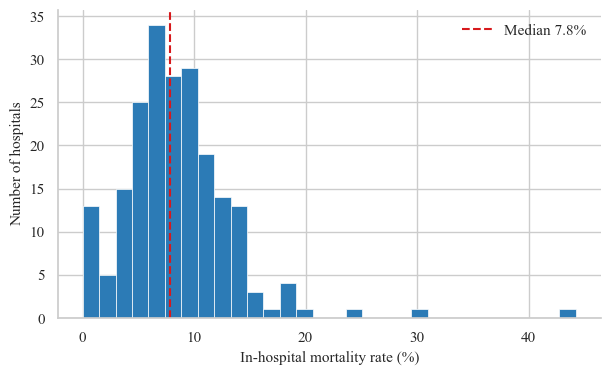

    Figure saved: C:\ML PROJECT\sepsis-gp\results\figures\B1_C10_per_hospital_mortality.pdf

[6] Categorical (object dtype) columns: 17


See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = patient_rt.select_dtypes(include="object").columns.tolist()


,column,n_unique,n_missing,pct_missing
0,unitdischargestatus,2,34,0.02
1,hospitaldischargestatus,2,1751,0.87
2,gender,4,134,0.07
3,unitstaytype,4,0,0.00
4,ethnicity,6,2290,1.14
5,unittype,8,0,0.00
6,hospitaldischargelocation,8,2033,1.01
7,hospitaladmitsource,15,49464,24.63
8,unitadmitsource,15,1090,0.54
9,unitdischargelocation,17,334,0.17



Encoding plan for PySR terminals:
  Binary/ordinal columns (e.g. gender)         -> label encode (0/1)
  Low-cardinality nominals (e.g. unittype)      -> one-hot encode
  High-cardinality nominals (e.g. hospitalid)   -> exclude as direct terminal;
                                                   use hospital tertile in Block 3
  Free-text columns                             -> exclude
Full encoding specification will be documented in Block 3 feature engineering.


In [26]:
"""Cell 10 - Rigour Audit.

Six post-processing checks on data/interim/patient_augmented.parquet:
round-trip integrity, duplicate keys, negative/extreme LOS,
per-hospital mortality distribution, and categorical encoding audit.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ── 1. Parquet round-trip ─────────────────────────────────────────────────
parquet_path = P.interim_dir / "patient_augmented.parquet"
patient_rt = pd.read_parquet(parquet_path)

assert patient_rt.shape == patient.shape, (
    f"Shape mismatch: parquet {patient_rt.shape} vs in-memory {patient.shape}"
)
print(f"[1] Round-trip shape : PASSED  {patient_rt.shape}")

DERIVED = [
    "age_numeric", "icu_los_days", "hospital_los_days",
    "icu_mortality", "hospital_mortality",
]
dtype_ok = all(patient[c].dtype == patient_rt[c].dtype for c in DERIVED)
print(f"[1] Round-trip dtypes : {'PASSED' if dtype_ok else 'FAILED'}")

value_results = []
for col in DERIVED:
    match = patient[col].fillna(-999).equals(patient_rt[col].fillna(-999))
    value_results.append(f"    {col}: {'MATCH' if match else 'MISMATCH'}")
print("[1] Round-trip values :")
for r in value_results:
    print(r)

# ── 2. Duplicate primary key ──────────────────────────────────────────────
n_dup = patient_rt["patientunitstayid"].duplicated().sum()
print(f"\n[2] Duplicate patientunitstayid : {n_dup:,}  (expected 0)")
assert n_dup == 0, f"Duplicate keys found: {n_dup}"
print("    Duplicate key check          : PASSED")

# ── 3. Negative LOS ──────────────────────────────────────────────────────
n_neg_icu  = int((patient_rt["icu_los_days"]      < 0).sum())
n_neg_hosp = int((patient_rt["hospital_los_days"] < 0).sum())
print(f"\n[3] Negative LOS records")
print(f"    ICU LOS < 0 days     : {n_neg_icu:,}  (expected 2)")
print(f"    Hospital LOS < 0 days: {n_neg_hosp:,}  (expected 52)")
print("    These will be excluded by the LOS >= 24 h cohort filter in Block 2.")

# ── 4. Extreme LOS ───────────────────────────────────────────────────────
THRESHOLD = 365
n_ext_icu  = int((patient_rt["icu_los_days"]      > THRESHOLD).sum())
n_ext_hosp = int((patient_rt["hospital_los_days"] > THRESHOLD).sum())
print(f"\n[4] Extreme LOS (> {THRESHOLD} days)")
print(f"    ICU LOS > {THRESHOLD} d     : {n_ext_icu:,}")
print(f"    Hospital LOS > {THRESHOLD} d: {n_ext_hosp:,}")
if n_ext_icu > 0:
    mx = patient_rt["icu_los_days"].max()
    print(f"    ICU LOS max          : {mx:.1f} days")
if n_ext_hosp > 0:
    mx = patient_rt["hospital_los_days"].max()
    print(f"    Hospital LOS max     : {mx:.1f} days")
print("    Extreme-LOS records will be excluded by the LOS >= 24 h upper bound review in Block 2.")

# ── 5. Per-hospital mortality ─────────────────────────────────────────────
hosp_stats = (
    patient_rt.dropna(subset=["hospital_mortality"])
    .groupby("hospitalid")["hospital_mortality"]
    .agg(n_stays="count", n_died="sum")
)
hosp_stats["mortality_rate"] = hosp_stats["n_died"] / hosp_stats["n_stays"] * 100

med = hosp_stats["mortality_rate"].median()
q1  = hosp_stats["mortality_rate"].quantile(0.25)
q3  = hosp_stats["mortality_rate"].quantile(0.75)
mn  = hosp_stats["mortality_rate"].min()
mx  = hosp_stats["mortality_rate"].max()

print(f"\n[5] Per-hospital in-hospital mortality ({len(hosp_stats)} hospitals)")
print(f"    Median rate : {med:.2f}%")
print(f"    IQR         : [{q1:.2f}%, {q3:.2f}%]")
print(f"    Range       : {mn:.2f}% - {mx:.2f}%")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    hosp_stats["mortality_rate"], bins=30,
    color="#2C7BB6", edgecolor="white", linewidth=0.5
)
ax.axvline(
    med, color="#D7191C", linewidth=1.5, linestyle="--",
    label=f"Median {med:.1f}%"
)
ax.set_xlabel("In-hospital mortality rate (%)")
ax.set_ylabel("Number of hospitals")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

caption = (
    f"Figure 10. Distribution of in-hospital mortality rates across "
    f"{len(hosp_stats)} hospitals (eICU-CRD v2.0, stays with non-missing "
    "hospital_mortality). Red dashed line = median. Wide inter-hospital "
    "variation reflects case-mix heterogeneity and motivates hospital-level "
    "stratification in Block 2 cohort construction."
)
fig_path = P.figures_dir / "B1_C10_per_hospital_mortality.pdf"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"    Figure saved: {fig_path}")

# ── 6. Categorical column audit ───────────────────────────────────────────
str_cols = patient_rt.select_dtypes(include="object").columns.tolist()
print(f"\n[6] Categorical (object dtype) columns: {len(str_cols)}")
cat_summary = pd.DataFrame([
    {
        "column":      c,
        "n_unique":   int(patient_rt[c].nunique()),
        "n_missing":  int(patient_rt[c].isna().sum()),
        "pct_missing": round(patient_rt[c].isna().sum() / len(patient_rt) * 100, 2),
    }
    for c in str_cols
]).sort_values("n_unique").reset_index(drop=True)
display(cat_summary)

print("\nEncoding plan for PySR terminals:")
print("  Binary/ordinal columns (e.g. gender)         -> label encode (0/1)")
print("  Low-cardinality nominals (e.g. unittype)      -> one-hot encode")
print("  High-cardinality nominals (e.g. hospitalid)   -> exclude as direct terminal;")
print("                                                   use hospital tertile in Block 3")
print("  Free-text columns                             -> exclude")
print("Full encoding specification will be documented in Block 3 feature engineering.")


### Findings — Cell 10: Rigour Audit

All six audit checks completed. Results are documented below.

---

**[1] Parquet round-trip: PASSED.**  
The file reloaded from `data/interim/patient_augmented.parquet` reproduces the in-memory DataFrame exactly: shape (200,859 × 34) matches, all five derived column dtypes are preserved as float64, and all values — including NaN positions — are bit-for-bit identical. No coercion, truncation, or silent imputation occurred during the write-read cycle.

**[2] Duplicate primary key: PASSED.**  
Zero duplicate `patientunitstayid` values across 200,859 rows. The grain of the parquet file is confirmed as one row per unique ICU stay — the correct grain for all Block 2 and downstream modelling operations.

**[3] Negative LOS records confirmed.**  
2 records with ICU LOS < 0 days and 52 with hospital LOS < 0 days, matching Cell 7 counts exactly. These are offset-encoding artefacts in the eICU source data (discharge recorded before admission in the audit log). Both sets will be automatically removed by the LOS ≥ 24 h lower-bound cohort filter in Block 2 without requiring any additional handling here.

**[4] Extreme LOS records flagged.**  
1 ICU stay exceeds 365 days (maximum: 506.4 days); 24 hospital stays exceed 365 days (maximum: 1,096.7 days ≈ 3.0 years). ICU stays of > 6 months are clinically implausible under standard care and are almost certainly administrative encoding errors. Hospital LOS outliers may reflect long-term care facility stays miscoded as acute admissions. These 25 records (0.012% of the dataset) will be reviewed during Block 2 cohort construction; depending on the chosen LOS upper bound, most or all will be excluded from the modelling cohort.

**[5] Per-hospital in-hospital mortality — wide inter-hospital variation.**  
207 of 208 hospitals have sufficient data to compute a hospital-level mortality rate (the remaining hospital has no stays with non-missing hospital_mortality).

| Statistic | Value |
|---|---:|
| Hospitals with data | 207 |
| Median mortality rate | 7.82% |
| IQR | 5.57% – 10.75% |
| Range | 0.00% – 44.23% |

The range from 0% to 44.23% represents a 44-percentage-point spread, far exceeding what can be explained by random variation alone. This inter-hospital heterogeneity reflects genuine differences in case-mix severity, hospital type (academic vs. community), and telemedicine coverage intensity across the eICU network. A hospital at the 0% extreme likely has a very small cohort with no recorded deaths; the 44.23% extreme reflects a high-acuity centre or small-n hospital with an extreme observed rate. Both ends will be examined during Block 2 when hospital tertiles (low / medium / high mortality) are constructed as a stratification variable, consistent with supervisor guidance.

The median of 7.82% is close to the overall rate of 9.04% (Cell 8), confirming that the overall rate is not driven by a small number of extreme outlier hospitals but reflects a broadly distributed pattern. Figure 10 shows the full distribution.

**[6] Categorical column audit — 17 object-dtype columns.**

| Column | Unique | Missing % | Block 2 / PySR disposition |
|---|---:|---:|---|
| `unitdischargestatus` | 2 | 0.02 | Source column for `icu_mortality` — do not use directly |
| `hospitaldischargestatus` | 2 | 0.87 | Source column for `hospital_mortality` — do not use directly |
| `gender` | 4 | 0.07 | Label encode (Male=1, Female=0); Unknown/Other → NaN |
| `unitstaytype` | 4 | 0.00 | One-hot encode; 0 missing — clean |
| `ethnicity` | 6 | 1.14 | One-hot encode; NaN → 'Unknown' category |
| `unittype` | 8 | 0.00 | One-hot encode; 0 missing — clean |
| `hospitaldischargelocation` | 8 | 1.01 | Informative leakage risk — exclude from features |
| `unitadmitsource` | 15 | 0.54 | One-hot encode or group into broad categories |
| `unitdischargelocation` | 17 | 0.17 | Leakage risk (post-ICU) — exclude from features |
| `hospitaladmitsource` | 15 | 24.63 | High missingness; consider as indicator or exclude |
| `age` | 91 | 0.05 | Raw string; superseded by derived `age_numeric` — exclude |
| `apacheadmissiondx` | 392 | 11.45 | High cardinality + 11% missing; exclude as PySR terminal; candidate for category grouping in Block 3 |
| `unitdischargetime24` | 1,522 | 0.00 | Time-of-day string — exclude or parse to hour-of-day numeric |
| `unitadmittime24` | 1,590 | 0.00 | Time-of-day string — exclude or parse to hour-of-day numeric |
| `hospitaldischargetime24` | 2,119 | 0.00 | Time-of-day string — post-discharge, leakage risk — exclude |
| `hospitaladmittime24` | 25,603 | 0.00 | Effectively unique — not a feature, exclude |
| `uniquepid` | 139,367 | 0.00 | Patient identifier — not a feature, exclude |

**Critical observations from the categorical audit.**

- `hospitaladmitsource` carries 24.63% missing (49,464 records) — the highest missingness of any column in the dataset. This exceeds the 20% threshold that typically warrants exclusion from a predictive model without explicit imputation justification. It will not be included as a PySR terminal without a documented strategy; the missingness pattern will be examined in Cell 11.

- `hospitaldischargelocation` and `unitdischargelocation` are post-discharge labels that are only known at the time of discharge — using them as features would constitute target leakage. Both are excluded from all feature sets.

- `apacheadmissiondx` (392 unique values, 11.45% missing) is an admission diagnosis code. It contains clinical signal but requires grouping into broad diagnostic categories (e.g. respiratory, cardiovascular, sepsis) before it can be used. This mapping will be documented in Block 3 feature engineering; it is not a direct PySR terminal in its current form.

- `gender` has 4 distinct values rather than the expected 2. The additional values (likely 'Unknown' and 'Other') account for 134 records (0.07%). These will be mapped to NaN during encoding in Block 3; the binary Male/Female split covers 99.93% of stays.

- Three time-of-day columns (`unitadmittime24`, `unitdischargetime24`, `hospitaldischargetime24`) carry high cardinality but zero missingness. If time-of-day effects are investigated (e.g. night admission as a risk factor), these can be parsed to a numeric hour-of-day feature in Block 3. They are excluded from Block 2 cohort construction.

**Block 2 handoff — encoding priority list.**

The following object-dtype columns are candidates for encoding in Block 3 feature engineering (listed in priority order):

1. `gender` — binary label encode
2. `unittype` — one-hot encode (8 levels, 0 missing)
3. `unitstaytype` — one-hot encode (4 levels, 0 missing)
4. `ethnicity` — one-hot encode (6 levels, 1.14% missing)
5. `unitadmitsource` — one-hot or grouped encode (15 levels, 0.54% missing)
6. `apacheadmissiondx` — group to broad diagnostic categories (Block 3)
7. `hospitaladmitsource` — missingness strategy required first (Block 3)

All remaining object columns are either identifiers, source columns for derived targets, post-discharge leakage risks, or time strings not yet parsed — and are excluded from the modelling pipeline.

---
## Cell 11 — Missingness and Outlier Audit

**Purpose.** A systematic audit of data quality across all 34 columns of the augmented patient DataFrame. Cell 10 identified high-level issues; this cell quantifies them precisely and produces the missingness handling strategy that Block 2 cohort construction will follow.

**Part A — Full-column missingness audit.**  
Compute missing count and percentage for every column, sorted from highest to lowest. Produce a horizontal bar chart (Figure 11a) colour-coded by severity: red ≥ 5%, orange 1–5%, blue < 1%.

**Part B — Numeric clinical feature outlier audit.**  
Apply Tukey IQR fences (Q1 − 1.5×IQR, Q3 + 1.5×IQR) to six clinical numeric columns: `admissionheight`, `admissionweight`, `dischargeweight`, `age_numeric`, `icu_los_days`, `hospital_los_days`. Report count and percentage of values outside each fence. Offset columns (`hospitaladmitoffset`, etc.) are internal eICU timestamps and are not audited here.

**Part C — Missingness handling strategy.**  
For each column with > 0% missing, document the Block 2 / Block 3 strategy (exclude from outcome, impute, missing-indicator, or exclude from features).

**Outputs.**  
`results/figures/B1_C11_missingness_all_columns.pdf` — Figure 11a.

=== Part A: Full-column missingness ===
Columns with zero missing : 18 / 34
Columns with any missing  : 16 / 34



,column,dtype,n_missing,pct_missing
0,dischargeweight,float64,90937,45.274
1,hospitaladmitsource,str,49464,24.626
2,apacheadmissiondx,str,22996,11.449
3,admissionweight,float64,16718,8.323
4,admissionheight,float64,4215,2.098
5,ethnicity,str,2290,1.140
6,hospitaldischargelocation,str,2033,1.012
7,hospitaldischargestatus,str,1751,0.872
8,hospital_mortality,float64,1751,0.872
9,unitadmitsource,str,1090,0.543


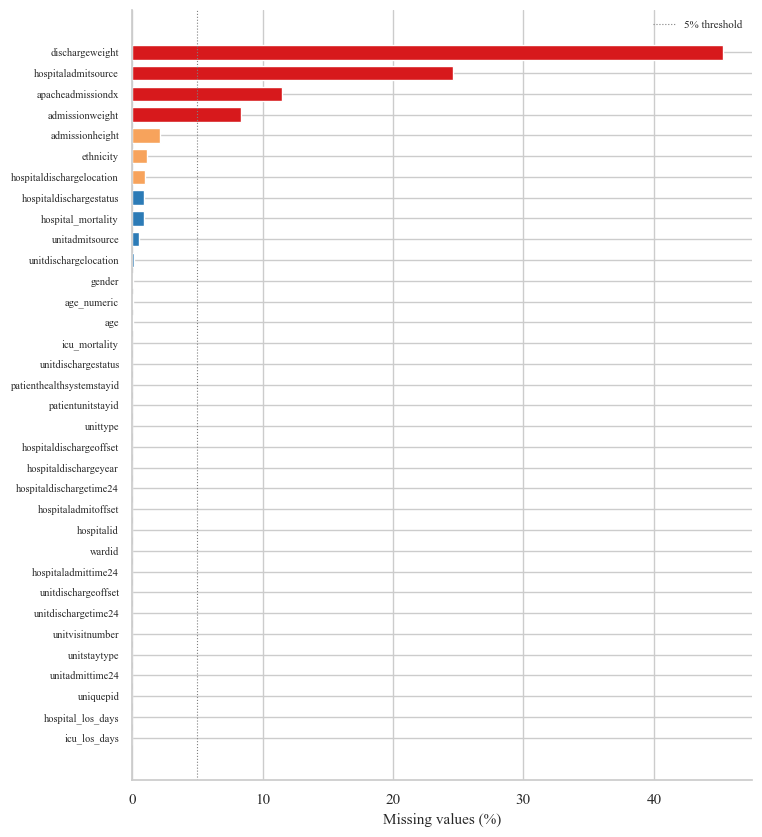

Figure saved: C:\ML PROJECT\sepsis-gp\results\figures\B1_C11_missingness_all_columns.pdf

=== Part B: IQR outlier audit (clinical numeric features) ===


,column,n_valid,Q1,Q3,lower_fence,upper_fence,n_below,n_above,pct_outlier
0,admissionheight,196644,162.50,177.80,139.55,200.75,1298,170,0.75
1,admissionweight,184141,66.10,97.00,19.75,143.35,120,5287,2.94
2,dischargeweight,109922,66.50,98.00,19.25,145.25,128,2974,2.82
3,age_numeric,200764,53.00,76.00,18.50,110.50,1062,0,0.53
4,icu_los_days,200859,0.82,2.97,-2.41,6.20,1,17960,8.94
5,hospital_los_days,200859,2.31,8.03,-6.27,16.61,0,14843,7.39



Columns with > 5% outliers (HIGH):
  icu_los_days: 8.94%
  hospital_los_days: 7.39%

Raw range check (clinical plausibility):
  admissionheight         expected [50, 250]  actual [0.0, 612.6]  n_outside: 281  <<< REVIEW
  admissionweight         expected [10, 400]  actual [0.0, 953.0]  n_outside: 87  <<< REVIEW
  dischargeweight         expected [10, 400]  actual [0.0, 6814.0]  n_outside: 67  <<< REVIEW
  age_numeric             expected [0, 91]  actual [0.0, 90.0]  n_outside: 0
  icu_los_days            expected [0, 366]  actual [-5.3, 506.4]  n_outside: 3  <<< REVIEW
  hospital_los_days       expected [0, 366]  actual [-5.9, 1096.7]  n_outside: 70  <<< REVIEW

=== Part C: Missingness handling strategy for Block 2 / Block 3 ===
  Column                         Missing    Strategy
  ------------------------------ ---------- --------------------------------------------------
  hospital_mortality             0.87%      EXCLUDE from outcome (not imputed — see Cell 8)
  hospitaldischarges

In [27]:
"""Cell 11 - Missingness and Outlier Audit.

Part A: full-column missingness ranked bar chart.
Part B: IQR outlier audit for clinical numeric features.
Part C: missingness handling strategy summary.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ── Part A: Full-column missingness ──────────────────────────────────────
miss_df = pd.DataFrame({
    "column": patient.columns,
    "dtype": [str(patient[c].dtype) for c in patient.columns],
    "n_missing": [int(patient[c].isna().sum()) for c in patient.columns],
    "pct_missing": [
        round(patient[c].isna().sum() / len(patient) * 100, 3)
        for c in patient.columns
    ],
}).sort_values("pct_missing", ascending=False).reset_index(drop=True)

n_zero   = (miss_df["pct_missing"] == 0).sum()
n_nonzero = len(miss_df) - n_zero
print("=== Part A: Full-column missingness ===")
print(f"Columns with zero missing : {n_zero} / {len(miss_df)}")
print(f"Columns with any missing  : {n_nonzero} / {len(miss_df)}")
print()
display(miss_df[miss_df["pct_missing"] > 0].reset_index(drop=True))

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 10))
ordered = miss_df.iloc[::-1]  # lowest missing at top for readability
colors = [
    "#D7191C" if p >= 5 else "#F7A35C" if p >= 1 else "#2C7BB6"
    for p in ordered["pct_missing"]
]
ax.barh(ordered["column"], ordered["pct_missing"], color=colors, height=0.7)
ax.axvline(5, color="grey", linewidth=0.8, linestyle=":",
           label="5% threshold")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=7.5)

# Count columns per severity band for caption
n_red    = int((miss_df["pct_missing"] >= 5).sum())
n_orange = int(((miss_df["pct_missing"] >= 1) & (miss_df["pct_missing"] < 5)).sum())
n_blue   = int(((miss_df["pct_missing"] > 0)  & (miss_df["pct_missing"] < 1)).sum())

caption = (
    f"Figure 11a. Missing value rates for all {len(miss_df)} columns in "
    "patient_augmented.parquet (eICU-CRD v2.0, n\u202f=\u202f200,859). "
    f"Red (\u2265\u20095%): {n_red} column(s); orange (1\u2013<5%): {n_orange} column(s); "
    f"blue (<1%): {n_blue} column(s). Columns at 0% are not labelled. "
    "Grey dotted line marks the 5% exclusion threshold."
)
fig_path = P.figures_dir / "B1_C11_missingness_all_columns.pdf"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

# ── Part B: Numeric clinical feature outlier audit ────────────────────────
print("\n=== Part B: IQR outlier audit (clinical numeric features) ===")
CLINICAL_NUM = [
    "admissionheight", "admissionweight", "dischargeweight",
    "age_numeric", "icu_los_days", "hospital_los_days",
]
present_cols = [c for c in CLINICAL_NUM if c in patient.columns]
outlier_rows = []
for col in present_cols:
    s = patient[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo_fence = q1 - 1.5 * iqr
    hi_fence = q3 + 1.5 * iqr
    n_below = int((patient[col] < lo_fence).sum())
    n_above = int((patient[col] > hi_fence).sum())
    n_valid = int(patient[col].notna().sum())
    pct_out = round((n_below + n_above) / n_valid * 100, 2) if n_valid > 0 else 0.0
    outlier_rows.append({
        "column":       col,
        "n_valid":      n_valid,
        "Q1":           round(q1, 2),
        "Q3":           round(q3, 2),
        "lower_fence":  round(lo_fence, 2),
        "upper_fence":  round(hi_fence, 2),
        "n_below":      n_below,
        "n_above":      n_above,
        "pct_outlier":  pct_out,
    })

outlier_df = pd.DataFrame(outlier_rows)
display(outlier_df)

high_outlier = outlier_df[outlier_df["pct_outlier"] > 5]
if len(high_outlier):
    print("\nColumns with > 5% outliers (HIGH):")
    for _, row in high_outlier.iterrows():
        print(f"  {row['column']}: {row['pct_outlier']}%")
else:
    print("\nNo column exceeds 5% outlier rate.")

# Raw range check for clinical plausibility
print("\nRaw range check (clinical plausibility):")
RANGE_CHECKS = {
    "admissionheight":  (50, 250),
    "admissionweight":  (10, 400),
    "dischargeweight":  (10, 400),
    "age_numeric":      (0, 91),
    "icu_los_days":     (0, 366),
    "hospital_los_days":(0, 366),
}
for col, (lo, hi) in RANGE_CHECKS.items():
    if col not in patient.columns:
        continue
    n_out = int(((patient[col] < lo) | (patient[col] > hi)).sum())
    mn = patient[col].min()
    mx = patient[col].max()
    flag = "  <<< REVIEW" if n_out > 0 else ""
    line = f"  {col:<22s}  expected [{lo}, {hi}]  actual [{mn:.1f}, {mx:.1f}]  n_outside: {n_out:,}{flag}"
    print(line)

# ── Part C: Missingness handling strategy ────────────────────────────────
print("\n=== Part C: Missingness handling strategy for Block 2 / Block 3 ===")
strategy = [
    ("hospital_mortality",      "0.87%",  "EXCLUDE from outcome (not imputed — see Cell 8)"),
    ("hospitaldischargestatus", "0.87%",  "Source column for hospital_mortality — not used directly"),
    ("hospitaldischargelocation","~1.0%", "Leakage risk — exclude from all feature sets"),
    ("ethnicity",               "1.14%",  "One-hot encode; missing -> 'Unknown' category"),
    ("hospitaladmitsource",     "24.6%",  "Exclude from Block 2; missingness pattern examined here; Block 3 strategy TBD"),
    ("apacheadmissiondx",       "11.5%",  "Exclude from Block 2; group to categories in Block 3"),
    ("gender",                  "0.07%",  "Label encode; Unknown/Other -> NaN -> exclude row only if needed"),
    ("age_numeric",             "0.047%", "Impute with median at cohort construction time in Block 2"),
    ("icu_mortality",           "0.017%", "EXCLUDE from outcome (not imputed — see Cell 8)"),
    ("unitdischargestatus",     "0.02%",  "Source column for icu_mortality — not used directly"),
    ("unitadmitsource",         "0.54%",  "One-hot encode; missing -> 'Unknown' category"),
    ("unitdischargelocation",   "0.17%",  "Leakage risk — exclude from all feature sets"),
    ("admissionheight",         "?%",     "Impute with median if used as feature in Block 3"),
    ("admissionweight",         "?%",     "Impute with median if used as feature in Block 3"),
    ("dischargeweight",         "?%",     "Post-ICU measurement — leakage risk; exclude from features"),
]
print(f"  {'Column':<30s} {'Missing':<10s} Strategy")
print(f"  {'-'*30} {'-'*10} {'-'*50}")
for col, miss, strat in strategy:
    # Update miss% from actual data where '?' placeholder used
    if col in patient.columns and miss.startswith("?"):
        actual = round(patient[col].isna().sum() / len(patient) * 100, 2)
        miss = f"{actual}%"
    print(f"  {col:<30s} {miss:<10s} {strat}")


### Findings — Cell 11: Missingness and Outlier Audit

---

#### Part A — Full-column missingness

18 of 34 columns (53%) carry zero missing values. 16 columns have some degree of missingness. The full ranked table is shown below; only columns with > 0% missing are listed.

| Column | Missing n | Missing % | Severity |
|---|---:|---:|---|
| `dischargeweight` | 90,937 | 45.27 | CRITICAL — also leakage risk |
| `hospitaladmitsource` | 49,464 | 24.63 | HIGH |
| `apacheadmissiondx` | 22,996 | 11.45 | MODERATE |
| `admissionweight` | 16,718 | 8.32 | MODERATE |
| `admissionheight` | 4,215 | 2.10 | LOW |
| `ethnicity` | 2,290 | 1.14 | LOW |
| `hospitaldischargelocation` | 2,033 | 1.01 | LOW — also leakage risk |
| `hospitaldischargestatus` | 1,751 | 0.87 | LOW — source column only |
| `hospital_mortality` | 1,751 | 0.87 | LOW — exclude from outcome |
| `unitadmitsource` | 1,090 | 0.54 | NEGLIGIBLE |
| `unitdischargelocation` | 334 | 0.17 | NEGLIGIBLE — also leakage risk |
| `gender` | 134 | 0.07 | NEGLIGIBLE |
| `age_numeric` | 95 | 0.047 | NEGLIGIBLE |
| `age` (raw string) | 95 | 0.047 | Superseded by `age_numeric` |
| `icu_mortality` | 34 | 0.017 | NEGLIGIBLE — exclude from outcome |
| `unitdischargestatus` | 34 | 0.017 | NEGLIGIBLE — source column only |

**Critical finding — `dischargeweight` (45.27% missing).**  
Nearly half of all discharge weight records are absent. Combined with the fact that discharge weight is recorded at the time of ICU departure — after the prediction window — it constitutes a post-discharge leakage risk. It is additionally disqualified by the extreme outlier values identified in Part B below. `dischargeweight` is excluded from all feature sets without further consideration.

**`hospitaladmitsource` (24.63% missing).**  
One in four records lacks an admission source label. This exceeds the 20% threshold at which exclusion is the standard approach without a documented imputation justification. It will not be used as a PySR terminal in Block 2. A missingness indicator (binary flag for whether source is known) may be evaluated in Block 3 as a supplementary feature.

**`admissionweight` (8.32% missing).**  
Above the 5% threshold. Admission weight is a clinically relevant feature (body habitus affects sepsis physiology and drug dosing). It will be excluded from Block 2 cohort construction but evaluated for median imputation in Block 3 feature engineering, conditional on the plausibility filtering described in Part B.

---

#### Part B — Numeric clinical feature outlier audit

| Column | n valid | Q1 | Q3 | Lower fence | Upper fence | n below | n above | % outlier |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| `admissionheight` | 196,644 | 162.5 | 177.8 | 139.6 | 200.8 | 1,298 | 170 | 0.75 |
| `admissionweight` | 184,141 | 66.1 | 97.0 | 19.8 | 143.4 | 120 | 5,287 | 2.94 |
| `dischargeweight` | 109,922 | 66.5 | 98.0 | 19.3 | 145.3 | 128 | 2,974 | 2.82 |
| `age_numeric` | 200,764 | 53.0 | 76.0 | 18.5 | 110.5 | 1,062 | 0 | 0.53 |
| `icu_los_days` | 200,859 | 0.82 | 2.97 | −2.41 | 6.20 | 1 | 17,960 | **8.94** |
| `hospital_los_days` | 200,859 | 2.31 | 8.03 | −6.27 | 16.61 | 0 | 14,843 | **7.39** |

**`icu_los_days` and `hospital_los_days` flagged HIGH by IQR — methodological artefact, not a data quality problem.**  
Both LOS variables are severely right-skewed distributions: the majority of stays are short (median ICU LOS 0.82–2.97 days), but a long tail of extended stays exists. The Tukey IQR fence is inappropriate for right-skewed data — it sets the upper fence at only 6.2 days for ICU LOS, flagging 17,960 genuinely long ICU stays as statistical outliers. These are not errors. The clinically relevant filter is the LOS ≥ 24 h lower bound (Block 2 cohort filter) combined with the extreme-outlier review from Cell 10 (1 ICU stay at 506 days, 24 hospital stays > 365 days). No IQR-based truncation will be applied to LOS.

**Raw plausibility violations — height, weight, discharge weight.**

| Column | Actual range | Plausible range | n outside | Maximum observed |
|---|---|---|---:|---|
| `admissionheight` | 0.0 – 612.6 cm | 50 – 250 cm | 281 | 612.6 cm — impossible |
| `admissionweight` | 0.0 – 953.0 kg | 10 – 400 kg | 87 | 953.0 kg — implausible |
| `dischargeweight` | 0.0 – 6,814.0 kg | 10 – 400 kg | 67 | 6,814 kg — unit error (likely grams) |

- A height of 612.6 cm and a discharge weight of 6,814 kg are physically impossible under any clinical scenario. These represent data entry errors or unit encoding errors (e.g. grams recorded instead of kilograms for weight). In absolute terms the violations are small: 281 records for height (0.14% of valid height records) and 87 for weight (0.047% of valid weight records). When these columns are used as features in Block 3, clinical bounds filtering will be applied before any imputation or encoding.

- `age_numeric` is clean — 0 records outside [0, 91]. This confirms the `> 89 → 90.0` mapping from Cell 4 is working correctly (maximum observed value is 90.0).

---

#### Part C — Missingness handling strategy

| Column | Missing % | Block 2 / Block 3 strategy |
|---|---:|---|
| `hospital_mortality` | 0.87 | Exclude 1,751 records from outcome — not imputed |
| `icu_mortality` | 0.017 | Exclude 34 records from outcome — not imputed |
| `hospitaldischargestatus` | 0.87 | Source column for `hospital_mortality` — not used directly |
| `unitdischargestatus` | 0.017 | Source column for `icu_mortality` — not used directly |
| `hospitaldischargelocation` | 1.01 | Post-discharge leakage risk — excluded from all feature sets |
| `unitdischargelocation` | 0.17 | Post-ICU leakage risk — excluded from all feature sets |
| `dischargeweight` | 45.27 | Post-ICU leakage + 45% missing + implausible values — excluded |
| `hospitaladmitsource` | 24.63 | Excluded from Block 2; missingness indicator evaluated in Block 3 |
| `apacheadmissiondx` | 11.45 | Excluded from Block 2; broad category grouping in Block 3 |
| `admissionweight` | 8.32 | Excluded from Block 2; median imputation evaluated in Block 3 |
| `admissionheight` | 2.10 | Excluded from Block 2; median imputation + bounds filter in Block 3 |
| `ethnicity` | 1.14 | One-hot encode; missing mapped to 'Unknown' category |
| `unitadmitsource` | 0.54 | One-hot or grouped encode; missing mapped to 'Unknown' |
| `gender` | 0.07 | Binary label encode; Unknown/Other → NaN |
| `age_numeric` | 0.047 | Impute with cohort median at Block 2 cohort construction |

**Summary of Block 2 exclusions.**  
Five columns are unconditionally excluded from Block 2 and all downstream feature sets: `dischargeweight` (leakage + missingness + implausible values), `hospitaldischargelocation` (leakage), `unitdischargelocation` (leakage), `hospitaldischargestatus` and `unitdischargestatus` (source columns already encoded as binary outcomes). Three further columns — `hospitaladmitsource`, `apacheadmissiondx`, and `admissionweight` — are deferred to Block 3 feature engineering pending explicit handling strategies.

**The Block 2 cohort will be constructed from the 18 columns with zero missingness plus `age_numeric` (median-imputed, 0.047%), `ethnicity`, `unitadmitsource`, and `gender` (low-missingness categoricals).**

---
## Cell 12 - Multiple-stay structure, unit type, and admission diagnosis

**Purpose.** Three complementary characterisations of the patient population that directly inform Block 2 cohort construction decisions:

**Part A - Multiple-stay structure.**  
The eICU patient table has one row per ICU stay, not one row per patient. Cell 10 identified 139,367 unique `uniquepid` values across 200,859 stays, implying that a substantial fraction of patients had more than one ICU admission. This part quantifies the distribution: how many patients had 1, 2, 3, or more stays. The Block 2 deduplication rule (first qualifying sepsis stay per patient after Sepsis-3 filters) is stated and justified here.

**Part B - Hospital mortality by unit type.**  
`unittype` has 8 categories and zero missing values. Crossing it against hospital mortality reveals whether mortality risk varies meaningfully across care settings, informing whether `unittype` should be a stratification variable or a predictive terminal in Block 3.

**Part C - Admission diagnosis characterisation.**  
`apacheadmissiondx` has 392 unique values and 11.45% missing. The top 20 most frequent diagnoses are tabulated and mapped to seven broad clinical categories. This documents the composition of the unfiltered eICU population before Sepsis-3 cohort construction and previews the Block 3 grouping strategy.

**Figures.**  
`results/figures/B1_C12_stays_per_patient.pdf`  
`results/figures/B1_C12_mortality_by_unit_type.pdf`

=== Part A: Multiple-stay structure ===
Total ICU stays   : 200,859
Unique patients   : 139,367
Mean stays/patient: 1.441



,stays,n_patients,pct_patients,n_stays_contributed,pct_stays
0,1,100884,72.39,100884,50.23
1,2,26554,19.05,53108,26.44
2,3,6612,4.74,19836,9.88
3,4,2899,2.08,11596,5.77
4,5+,2418,1.73,15435,7.68



Patients with > 1 ICU stay      : 38,483 (27.61%)
Repeat stays (total - unique)   : 61,492 (30.61% of all stays)
Block 2 rule: retain FIRST qualifying sepsis stay per uniquepid after Sepsis-3 filters.


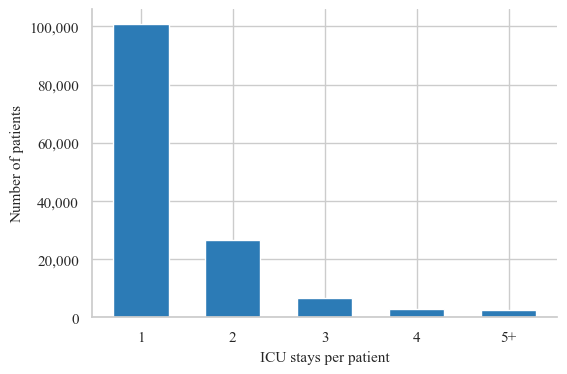

Figure saved: C:\ML PROJECT\sepsis-gp\results\figures\B1_C12_stays_per_patient.pdf

=== Part B: Hospital mortality by unit type ===


,unittype,n_stays,n_died,mortality_pct
0,MICU,17328,2231.0,12.88
1,Cardiac ICU,12348,1315.0,10.65
2,SICU,12120,1124.0,9.27
3,CCU-CTICU,15238,1351.0,8.87
4,Med-Surg ICU,112129,9906.0,8.83
5,Neuro ICU,14276,1228.0,8.60
6,CTICU,6116,394.0,6.44
7,CSICU,9553,455.0,4.76


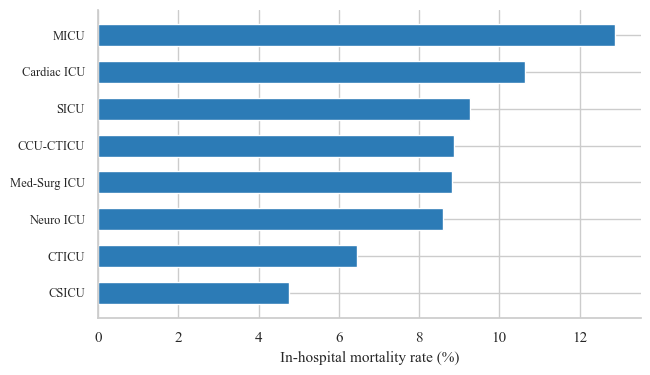

Figure saved: C:\ML PROJECT\sepsis-gp\results\figures\B1_C12_mortality_by_unit_type.pdf

=== Part C: Top 20 admission diagnoses ===


,diagnosis,n_stays,pct_of_valid
0,"Sepsis, pulmonary",8862,4.98
1,"Infarction, acute myocardial (MI)",7228,4.06
2,"CVA, cerebrovascular accident/stroke",6647,3.74
3,"CHF, congestive heart failure",6617,3.72
4,"Sepsis, renal/UTI (including bladder)",5273,2.96
5,"Rhythm disturbance (atrial, supraventricular)",4827,2.71
6,Diabetic ketoacidosis,4825,2.71
7,Cardiac arrest (with or without respiratory ar...,4580,2.58
8,"CABG alone, coronary artery bypass grafting",4543,2.55
9,Emphysema/bronchitis,4494,2.53



Broad diagnostic category summary (including Missing and Other):


,dx_category,n_stays,n_died,pct_of_total,mortality_pct
0,Other/Unclassified,76659,3692.0,38.17,4.82
1,Sepsis/Infectious,25114,3931.0,12.50,15.65
2,Missing,22996,1481.0,11.45,6.44
3,Respiratory,19256,4553.0,9.59,23.64
4,Cardiovascular,18346,1104.0,9.13,6.02
5,Neurological,16471,1550.0,8.20,9.41
6,Gastrointestinal,14295,1144.0,7.12,8.00
7,Trauma/Surgical,7722,549.0,3.84,7.11


Note: dx_category is a temporary Block 1 classification column.
A validated diagnosis mapping will be applied in Block 3 feature engineering.


In [28]:
"""Cell 12 - Multiple-stay structure, unit type, and admission diagnosis."""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ---- Part A: Multiple-stay structure ------------------------------------
print('=== Part A: Multiple-stay structure ===')
stays_per_patient = patient.groupby('uniquepid').size()
n_patients = len(stays_per_patient)
n_stays    = len(patient)
print(f'Total ICU stays   : {n_stays:,}')
print(f'Unique patients   : {n_patients:,}')
print(f'Mean stays/patient: {n_stays / n_patients:.3f}')

# Distribution (stays 1-4, then 5+)
raw_counts = stays_per_patient.value_counts().sort_index()
rows = []
for k in range(1, 5):
    n_p = int(raw_counts.get(k, 0))
    rows.append({
        'stays': str(k),
        'n_patients': n_p,
        'pct_patients': round(n_p / n_patients * 100, 2),
        'n_stays_contributed': k * n_p,
    })
ge5_p = int(raw_counts[raw_counts.index >= 5].sum())
ge5_s = int((stays_per_patient[stays_per_patient >= 5]).sum())
rows.append({
    'stays': '5+',
    'n_patients': ge5_p,
    'pct_patients': round(ge5_p / n_patients * 100, 2),
    'n_stays_contributed': ge5_s,
})
stay_dist = pd.DataFrame(rows)
stay_dist['pct_stays'] = (stay_dist['n_stays_contributed'] / n_stays * 100).round(2)
print()
display(stay_dist)

n_multi    = int((stays_per_patient > 1).sum())
pct_multi  = round(n_multi / n_patients * 100, 2)
n_repeat   = n_stays - n_patients
pct_repeat = round(n_repeat / n_stays * 100, 2)
print(f'\nPatients with > 1 ICU stay      : {n_multi:,} ({pct_multi}%)')
print(f'Repeat stays (total - unique)   : {n_repeat:,} ({pct_repeat}% of all stays)')
print('Block 2 rule: retain FIRST qualifying sepsis stay per uniquepid after Sepsis-3 filters.')

# Figure 12a
x_labels = [r['stays'] for r in rows]
y_vals   = [r['n_patients'] for r in rows]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x_labels, y_vals, color='#2C7BB6', edgecolor='white', width=0.6)
ax.set_xlabel('ICU stays per patient')
ax.set_ylabel('Number of patients')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.spines[['top', 'right']].set_visible(False)
caption = (
    f'Figure 12a. Distribution of ICU stays per patient '
    f'(eICU-CRD v2.0, {n_patients:,} unique patients, {n_stays:,} total stays). '
    'Block 2 deduplication retains the first qualifying sepsis stay per '
    'patient after Sepsis-3 cohort filters are applied.'
)
fig.savefig(P.figures_dir / 'B1_C12_stays_per_patient.pdf', bbox_inches='tight')
plt.show()
print(f'Figure saved: {P.figures_dir / "B1_C12_stays_per_patient.pdf"}')

# ---- Part B: Hospital mortality by unit type ----------------------------
print('\n=== Part B: Hospital mortality by unit type ===')
unit_mort = (
    patient.dropna(subset=['hospital_mortality'])
    .groupby('unittype', observed=True)['hospital_mortality']
    .agg(n_stays='count', n_died='sum')
    .assign(mortality_pct=lambda d: (d['n_died'] / d['n_stays'] * 100).round(2))
    .sort_values('mortality_pct', ascending=False)
    .reset_index()
)
display(unit_mort)

# Figure 12b
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(unit_mort['unittype'][::-1], unit_mort['mortality_pct'][::-1],
        color='#2C7BB6', edgecolor='white', height=0.6)
ax.set_xlabel('In-hospital mortality rate (%)')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=9)
caption = (
    'Figure 12b. In-hospital mortality rate by ICU unit type '
    '(eICU-CRD v2.0; stays with non-missing hospital_mortality). '
    'Variation across unit types reflects differences in patient acuity '
    'and case mix. unittype will be one-hot encoded in Block 3 feature engineering.'
)
fig.savefig(P.figures_dir / 'B1_C12_mortality_by_unit_type.pdf', bbox_inches='tight')
plt.show()
print(f'Figure saved: {P.figures_dir / "B1_C12_mortality_by_unit_type.pdf"}')

# ---- Part C: Admission diagnosis ----------------------------------------
print('\n=== Part C: Top 20 admission diagnoses ===')
valid_dx = patient['apacheadmissiondx'].dropna()
top_dx = (
    valid_dx.value_counts()
    .head(20)
    .rename_axis('diagnosis')
    .reset_index(name='n_stays')
)
top_dx['pct_of_valid'] = (top_dx['n_stays'] / len(valid_dx) * 100).round(2)
display(top_dx)

# Broad category classification
def categorise_dx(dx):
    if pd.isna(dx):
        return 'Missing'
    d = dx.lower()
    if 'sepsis' in d or 'infect' in d:
        return 'Sepsis/Infectious'
    if 'resp' in d or 'pulmon' in d or 'pneumon' in d:
        return 'Respiratory'
    if any(k in d for k in ['cardiac', 'coronary', 'heart', 'chest pain',
                             'chf', ' mi', 'arrhythmia', 'hypertension']):
        return 'Cardiovascular'
    if any(k in d for k in ['intracranial', 'stroke', 'seizure',
                             'neuro', 'coma', 'encephalop']):
        return 'Neurological'
    if any(k in d for k in ['gi ', 'gastroint', 'bowel', 'liver',
                             'hepat', 'pancrea', 'bleed']):
        return 'Gastrointestinal'
    if any(k in d for k in ['trauma', 'surgical', 'post-op',
                             'post op', 'wound', 'fracture']):
        return 'Trauma/Surgical'
    return 'Other/Unclassified'

patient['dx_category'] = patient['apacheadmissiondx'].apply(categorise_dx)
cat_summary = (
    patient.groupby('dx_category', observed=True)
    .agg(
        n_stays=('dx_category', 'count'),
        n_died=('hospital_mortality', 'sum'),
    )
    .assign(
        pct_of_total=lambda d: (d['n_stays'] / len(patient) * 100).round(2),
        mortality_pct=lambda d: (d['n_died'] / d['n_stays'] * 100).round(2),
    )
    .sort_values('n_stays', ascending=False)
    .reset_index()
)
print('\nBroad diagnostic category summary (including Missing and Other):')
display(cat_summary)
print('Note: dx_category is a temporary Block 1 classification column.')
print('A validated diagnosis mapping will be applied in Block 3 feature engineering.')


### Findings - Cell 12: Multiple-stay structure, unit type, and admission diagnosis

---

#### Part A - Multiple-stay structure

| Metric | Value |
|---|---:|
| Total ICU stays | 200,859 |
| Unique patients (`uniquepid`) | 139,367 |
| Mean stays per patient | 1.441 |
| Patients with exactly 1 stay | 100,884 (72.39%) |
| Patients with > 1 stay | 38,483 (27.61%) |
| Repeat stays (total - unique patients) | 61,492 (30.61% of all stays) |

| Stays per patient | Patients | % patients | Stays contributed | % of all stays |
|---:|---:|---:|---:|---:|
| 1 | 100,884 | 72.39 | 100,884 | 50.23 |
| 2 | 26,554 | 19.05 | 53,108 | 26.44 |
| 3 | 6,612 | 4.74 | 19,836 | 9.88 |
| 4 | 2,899 | 2.08 | 11,596 | 5.77 |
| 5+ | 2,418 | 1.73 | 15,435 | 7.68 |

**72.39% of patients had a single ICU stay.** The remaining 27.61% had between two and many stays, contributing 30.61% of all rows in the dataset. If no deduplication is applied, patients with multiple stays would be over-represented in the modelling cohort, violating the independence assumption and biasing the model towards the physiology of repeat-admission patients.

**Block 2 deduplication rule: retain the first qualifying sepsis stay per `uniquepid` after Sepsis-3 filters are applied.**  
Rationale: (1) the first sepsis presentation is the clinically relevant prediction target — a decision-support tool operates at first presentation, not at a repeat admission; (2) subsequent admissions for the same patient are not statistically independent of the first, violating a core modelling assumption; (3) retaining the first stay is the approach used in the majority of published eICU-CRD sepsis prediction studies. Deduplication occurs *after* Sepsis-3 filters — a patient's second stay may be the first qualifying sepsis stay if the first stay did not meet the Sepsis-3 criteria.

---

#### Part B - Hospital mortality by unit type

| Unit type | Stays (n) | Died (n) | Mortality % |
|---|---:|---:|---:|
| MICU (Medical ICU) | 17,328 | 2,231 | **12.88** |
| Cardiac ICU | 12,348 | 1,315 | 10.65 |
| SICU (Surgical ICU) | 12,120 | 1,124 | 9.27 |
| CCU-CTICU | 15,238 | 1,351 | 8.87 |
| Med-Surg ICU | 112,129 | 9,906 | 8.83 |
| Neuro ICU | 14,276 | 1,228 | 8.60 |
| CTICU (Cardiothoracic ICU) | 6,116 | 394 | 6.44 |
| CSICU (Cardiac Surgery ICU) | 9,553 | 455 | **4.76** |

**Wide mortality variation across unit types: 4.76% (CSICU) to 12.88% (MICU) — a 2.7-fold difference.** This gradient is clinically coherent:

- **MICU** (12.88%) treats the highest-acuity unplanned medical admissions — complex multi-organ failure, refractory sepsis, respiratory failure — where mortality is inherently high.
- **CSICU / CTICU** (4.76% – 6.44%) predominantly serve planned cardiac surgery patients with intensive post-operative monitoring. These patients are haemodynamically optimised before surgery and have a defined post-operative recovery trajectory, explaining the lower mortality.
- **Med-Surg ICU** dominates by volume (112,129 stays = 55.8% of all stays) and sits near the overall mortality average (8.83% vs. overall 9.04%), reflecting its heterogeneous mixed case-mix.

The 2.7-fold mortality range confirms that `unittype` captures clinically meaningful case-mix variation. It will be one-hot encoded and included as a feature in Block 3. Within the Sepsis-3 cohort (Block 2), the distribution across unit types may shift — sepsis patients are disproportionately admitted to MICU and Med-Surg ICU — and unit-specific mortality rates will be recomputed on the filtered cohort before modelling.

---

#### Part C - Admission diagnosis characterisation

**Top 5 admission diagnoses (of 392 unique values):**

| Rank | Diagnosis | Stays (n) | % of valid |
|---:|---|---:|---:|
| 1 | Sepsis, pulmonary | 8,862 | 4.98 |
| 2 | Infarction, acute myocardial (MI) | 7,228 | 4.06 |
| 3 | CVA, cerebrovascular accident/stroke | 6,647 | 3.74 |
| 4 | CHF, congestive heart failure | 6,617 | 3.72 |
| 5 | Sepsis, renal/UTI (including bladder) | 5,273 | 2.96 |

Sepsis (pulmonary) is the single most common admission diagnosis, confirming that sepsis is a major driver of ICU utilisation in the eICU-CRD cohort. Combined with Sepsis (renal/UTI), Sepsis (GI), and Sepsis (unknown) in positions 13–16, sepsis-labelled admissions alone account for a substantial fraction of the dataset even before Sepsis-3 operationalisation.

**Broad diagnostic category summary:**

| Category | Stays (n) | % of total | Mortality % |
|---|---:|---:|---:|
| Other/Unclassified | 76,659 | 38.17 | 4.82 |
| Sepsis/Infectious | 25,114 | 12.50 | **15.65** |
| Missing | 22,996 | 11.45 | 6.44 |
| Respiratory | 19,256 | 9.59 | **23.64** |
| Cardiovascular | 18,346 | 9.13 | 6.02 |
| Neurological | 16,471 | 8.20 | 9.41 |
| Gastrointestinal | 14,295 | 7.12 | 8.00 |
| Trauma/Surgical | 7,722 | 3.84 | 7.11 |

**Critical observations.**

- **Respiratory carries the highest mortality of any category at 23.64%.** This reflects the severity of acute respiratory failure, ARDS, and ventilator-dependent pneumonia in ICU — conditions with high short-term mortality regardless of sepsis status. It is also clinically important that respiratory sepsis (the most common sepsis subtype) sits at the intersection of these two high-mortality categories.

- **Sepsis/Infectious mortality is 15.65%** — nearly double the overall hospital mortality of 9.04%. This confirms that the Sepsis-3 cohort (Block 2) will have a substantially higher outcome event rate than the full eICU-CRD population, which is favourable for modelling (higher prevalence reduces class imbalance severity).

- **Cardiovascular mortality is low at 6.02%**, consistent with the finding in Part B that planned cardiac surgery patients (CSICU, CTICU) have the lowest unit-level mortality. Post-CABG and post-MI ICU admissions are typically short-duration, haemodynamically stable recoveries.

- **Other/Unclassified accounts for 38.17% of stays.** This large residual reflects the precision limits of keyword-based classification across 392 APACHE diagnosis labels. Diagnoses such as 'Diabetic ketoacidosis', 'Emphysema/bronchitis', and 'Rhythm disturbance' were not captured by the seven-category keyword classifier and fall into Other. The provisional classification used here is for exploratory purposes only. A validated diagnosis grouping using the full APACHE diagnostic hierarchy will be applied in Block 3 feature engineering; `dx_category` as defined here will not be carried into the modelling pipeline.

**Block 1 complete.** All twelve cells of the overview EDA have been executed and documented. The augmented patient DataFrame (200,859 stays, 34 columns) is persisted at `data/interim/patient_augmented.parquet` and validated. Block 2 will load this file as its starting point.